###This notebook reproduces and critically evaluates the methodology of Subrata Maji's UNSW-NB15 IDS tutorial.

#Downloading Necessary Files

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns
import sklearn

In [2]:
!git clone https://github.com/SubrataMaji/IDS-UNSW-NB15.git reference_IDS_UNSW_NB15
!find reference_IDS_UNSW_NB15 -maxdepth 2 -type f

Cloning into 'reference_IDS_UNSW_NB15'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 26 (delta 9), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 1.67 MiB | 8.86 MiB/s, done.
Resolving deltas: 100% (9/9), done.
reference_IDS_UNSW_NB15/2. EDA/Exploratory Data Analysis.ipynb
reference_IDS_UNSW_NB15/5. Predict data/Prediction of Raw Data.ipynb
reference_IDS_UNSW_NB15/README.md
reference_IDS_UNSW_NB15/.gitattributes
reference_IDS_UNSW_NB15/.git/index
reference_IDS_UNSW_NB15/.git/config
reference_IDS_UNSW_NB15/.git/HEAD
reference_IDS_UNSW_NB15/.git/description
reference_IDS_UNSW_NB15/.git/packed-refs
reference_IDS_UNSW_NB15/4. ML Models/ML Models and Results.ipynb
reference_IDS_UNSW_NB15/1. Dataset/About Dataset and It's Cleaning.ipynb
reference_IDS_UNSW_NB15/3. Preprocessing/Feature Engineering and Data Preparation.ipynb


In [3]:
!pip install -q kaggle xgboost

In [4]:
from google.colab import files

uploaded = files.upload()#uploading kaggle key in a json file

Saving kaggle.json to kaggle.json


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!rm -rf data/raw
!mkdir -p data/raw/full_csv

!kaggle datasets download -d mrwellsdavid/unsw-nb15 -p data/raw/full_csv --unzip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:07<00:00, 19.6MB/s]



In [7]:
!find data/raw/full_csv -maxdepth 4 -type f | head -100

data/raw/full_csv/NUSW-NB15_features.csv
data/raw/full_csv/UNSW_NB15_testing-set.csv
data/raw/full_csv/UNSW-NB15_LIST_EVENTS.csv
data/raw/full_csv/UNSW_NB15_training-set.csv
data/raw/full_csv/UNSW-NB15_4.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_1.csv


In [8]:
from pathlib import Path
import re

raw_dir = Path("data/raw/full_csv")

all_files = sorted([p for p in raw_dir.rglob("*") if p.is_file()])

print("All files found:")
for p in all_files[:100]:
    print(p)

csv_files = sorted(raw_dir.rglob("*.csv"))

print("\nCSV files found:")
for p in csv_files:
    print(p)

All files found:
data/raw/full_csv/NUSW-NB15_features.csv
data/raw/full_csv/UNSW-NB15_1.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_4.csv
data/raw/full_csv/UNSW-NB15_LIST_EVENTS.csv
data/raw/full_csv/UNSW_NB15_testing-set.csv
data/raw/full_csv/UNSW_NB15_training-set.csv

CSV files found:
data/raw/full_csv/NUSW-NB15_features.csv
data/raw/full_csv/UNSW-NB15_1.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_4.csv
data/raw/full_csv/UNSW-NB15_LIST_EVENTS.csv
data/raw/full_csv/UNSW_NB15_testing-set.csv
data/raw/full_csv/UNSW_NB15_training-set.csv


In [9]:
from pathlib import Path
import pandas as pd
import re

raw_dir = Path("data/raw/full_csv")
csv_files = sorted(raw_dir.rglob("*.csv"))

def normalize_name(path):
    return path.name.lower().replace("-", "").replace("_", "")

data_files = []

for i in range(1, 5):
    matches = [
        p for p in csv_files
        if f"unswnb15{i}.csv" in normalize_name(p)
    ]

    if not matches:
        raise FileNotFoundError(f"Could not find UNSW-NB15_{i}.csv")

    data_files.append(matches[0])

print("Using data files:")
for p in data_files:
    print(p)

feature_candidates = [
    p for p in csv_files
    if "features" in p.name.lower()
]

if not feature_candidates:
    raise FileNotFoundError("Could not find UNSW-NB15_features.csv or NUSW-NB15_features.csv")

features_path = feature_candidates[0]
print("\nUsing features file:")
print(features_path)

Using data files:
data/raw/full_csv/UNSW-NB15_1.csv
data/raw/full_csv/UNSW-NB15_2.csv
data/raw/full_csv/UNSW-NB15_3.csv
data/raw/full_csv/UNSW-NB15_4.csv

Using features file:
data/raw/full_csv/NUSW-NB15_features.csv


In [10]:
import gc

dfs = []

for path in data_files:
    print("Loading:", path)
    df_part = pd.read_csv(path, header=None, low_memory=False)
    print("Shape:", df_part.shape)
    dfs.append(df_part)

all_data = pd.concat(dfs, ignore_index=True, copy=False)

# Free the four separate CSV dataframes after concatenation.
del dfs, df_part
gc.collect()

print("\nCombined shape before column names:", all_data.shape)

features_df = pd.read_csv(features_path, encoding="ISO-8859-1")

display(features_df.head())
print(features_df.columns)

Loading: data/raw/full_csv/UNSW-NB15_1.csv
Shape: (700001, 49)
Loading: data/raw/full_csv/UNSW-NB15_2.csv
Shape: (700001, 49)
Loading: data/raw/full_csv/UNSW-NB15_3.csv
Shape: (700001, 49)
Loading: data/raw/full_csv/UNSW-NB15_4.csv
Shape: (440044, 49)

Combined shape before column names: (2540047, 49)


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol


Index(['No.', 'Name', 'Type ', 'Description'], dtype='object')


In [11]:
# Find the column that contains feature names
name_col_candidates = [
    col for col in features_df.columns
    if col.strip().lower() == "name"
]

if not name_col_candidates:
    raise ValueError("Could not find a 'Name' column in the features file.")

name_col = name_col_candidates[0]

column_names = (
    features_df[name_col]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.lower()
    .tolist()
)

print("Number of column names:", len(column_names))
print("Number of columns in all_data:", all_data.shape[1])

if len(column_names) != all_data.shape[1]:
    raise ValueError(
        f"Mismatch: features file has {len(column_names)} names, "
        f"but data has {all_data.shape[1]} columns."
    )

all_data.columns = column_names

print("Final shape:", all_data.shape)
display(all_data.head())

Number of column names: 49
Number of columns in all_data: 49
Final shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


In [12]:
# Clean string/categorical columns
for col in all_data.select_dtypes(include=["object"]).columns:
    all_data[col] = all_data[col].astype(str).str.strip()

# attack_cat sometimes has missing/blank values for normal traffic
if "attack_cat" in all_data.columns:
    all_data["attack_cat"] = all_data["attack_cat"].replace(["nan", "NaN", ""], "Normal")

# Use compact dtypes to reduce RAM before saving/continuing.
# The categorical columns are nominal strings, so category is much smaller than object.
for col in ["proto", "service", "state", "attack_cat"]:
    if col in all_data.columns:
        all_data[col] = all_data[col].astype("category")

# Downcast numeric columns where possible.
for col in all_data.columns:
    if col not in ["proto", "service", "state", "attack_cat"]:
        all_data[col] = pd.to_numeric(all_data[col], errors="coerce")
        if all_data[col].isna().any():
            all_data[col] = all_data[col].fillna(0)

        if pd.api.types.is_float_dtype(all_data[col]):
            all_data[col] = pd.to_numeric(all_data[col], downcast="float")
        elif pd.api.types.is_integer_dtype(all_data[col]):
            all_data[col] = pd.to_numeric(all_data[col], downcast="integer")

if "label" in all_data.columns:
    all_data["label"] = all_data["label"].astype("int8")

print(all_data.shape)
print(all_data.dtypes.value_counts())
print("Estimated memory usage (MB):", all_data.memory_usage(deep=True).sum() / 1024**2)

if "label" in all_data.columns:
    print(all_data["label"].value_counts())

if "attack_cat" in all_data.columns:
    print(all_data["attack_cat"].value_counts())

(2540047, 49)
float32     13
int16       11
int8        10
int32        5
float64      4
int64        2
category     1
category     1
category     1
category     1
Name: count, dtype: int64
Estimated memory usage (MB): 380.3276786804199
label
0    2218764
1     321283
Name: count, dtype: int64
attack_cat
Normal            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             1795
Shellcode            1511
Backdoors             534
Worms                 174
Name: count, dtype: int64


In [13]:
from pathlib import Path

processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

all_data.to_parquet("data/processed/unsw_nb15_full_all.parquet", index=False)

print("Saved:")
!ls -lh data/processed

Saved:
total 165M
-rw-r--r-- 1 root root 165M Jul 15 16:06 unsw_nb15_full_all.parquet


In [14]:
import pandas as pd

all_data = pd.read_parquet("data/processed/unsw_nb15_full_all.parquet")

print(all_data.shape)
display(all_data.head())

(2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,0.0,1390.0,0.0,53.0,udp,CON,0.001055,132,164,31,...,0.0,3,7,1,3,1,1,1,Normal,0
1,0.0,33661.0,0.0,1024.0,udp,CON,0.036133,528,304,31,...,0.0,2,4,2,3,1,1,2,Normal,0
2,0.0,1464.0,0.0,53.0,udp,CON,0.001119,146,178,31,...,0.0,12,8,1,2,2,1,1,Normal,0
3,0.0,3593.0,0.0,53.0,udp,CON,0.001209,132,164,31,...,0.0,6,9,1,1,1,1,1,Normal,0
4,0.0,49664.0,0.0,53.0,udp,CON,0.001169,146,178,31,...,0.0,7,9,1,1,1,1,1,Normal,0


## Duplicate Row Analysis

In [15]:
import pandas as pd
import numpy as np
import gc
from pandas.util import hash_pandas_object

print("Original all_data shape:", all_data.shape)

# Count exact duplicated rows in the full concatenated dataset.
# Avoid all_data.drop_duplicates() here because it creates another huge dataframe.
duplicate_mask = all_data.duplicated()
num_duplicated_rows = int(duplicate_mask.sum())
num_unique_rows = len(all_data) - num_duplicated_rows

print("Number of duplicated rows:", num_duplicated_rows)
print("Number of unique rows:", num_unique_rows)
print("Duplicate percentage:", num_duplicated_rows / len(all_data) * 100)

del duplicate_mask
gc.collect()

Original all_data shape: (2540047, 49)
Number of duplicated rows: 481062
Number of unique rows: 2058985
Duplicate percentage: 18.939098371014396


9

In [16]:
from sklearn.model_selection import train_test_split

# To check leakage from a random split, split row hashes instead of creating
# full train_df/test_df copies. This saves a lot of RAM.
target_col = "label"
all_data[target_col] = all_data[target_col].astype("int8")

all_row_hashes = hash_pandas_object(all_data, index=False).astype("uint64")

train_hashes, test_hashes = train_test_split(
    all_row_hashes,
    test_size=0.2,
    stratify=all_data[target_col],
    random_state=42
)

print("Number of row hashes in random train split:", len(train_hashes))
print("Number of row hashes in random test split:", len(test_hashes))

Number of row hashes in random train split: 2032037
Number of row hashes in random test split: 508010


In [17]:
# Compute direct train-test duplicate overlap for the random split.
train_hash_set = set(train_hashes.to_numpy())

test_rows_overlapping_train = test_hashes.isin(train_hash_set).sum()
test_overlap_percentage = test_rows_overlapping_train / len(test_hashes) * 100

print("Test rows with exact duplicate also present in train:", test_rows_overlapping_train)
print("Percentage of test rows overlapping train:", test_overlap_percentage)

# Free temporary hash objects before creating the deduplicated dataset.
del all_row_hashes, train_hashes, test_hashes, train_hash_set
gc.collect()

Test rows with exact duplicate also present in train: 110627
Percentage of test rows overlapping train: 21.776539831893075


0

### Duplicate Leakage Observation

After concatenating the four raw UNSW-NB15 CSV files and performing a random train-test split, I checked for exact duplicate rows. This is important because if identical records appear in both the training and test sets, the test performance may be overly optimistic. In that case, the model may partly be recognizing repeated records rather than generalizing to genuinely unseen traffic.

## Deduplicated Dataset Experiment

In [18]:
# Remove exact duplicate rows before splitting.
# ignore_index=True avoids an extra reset_index copy.
dedup_data = all_data.drop_duplicates(ignore_index=True)

print("Original dataset shape:", all_data.shape)
print("Deduplicated dataset shape:", dedup_data.shape)
print("Rows removed:", len(all_data) - len(dedup_data))
print("Removed percentage:", (len(all_data) - len(dedup_data)) / len(all_data) * 100)

Original dataset shape: (2540047, 49)
Deduplicated dataset shape: (2058985, 49)
Rows removed: 481062
Removed percentage: 18.939098371014396


In [19]:
from sklearn.model_selection import train_test_split
import gc

target_col = "label"

dedup_data[target_col] = dedup_data[target_col].astype("int8")

train_df_dedup, test_df_dedup = train_test_split(
    dedup_data,
    test_size=0.2,
    stratify=dedup_data[target_col],
    random_state=42
)

train_df_dedup = train_df_dedup.reset_index(drop=True)
test_df_dedup = test_df_dedup.reset_index(drop=True)

print("Deduplicated train shape:", train_df_dedup.shape)
print("Deduplicated test shape:", test_df_dedup.shape)

print("\nDeduplicated train label distribution:")
print(train_df_dedup[target_col].value_counts(normalize=True))

print("\nDeduplicated test label distribution:")
print(test_df_dedup[target_col].value_counts(normalize=True))

# The model uses only the deduplicated split from this point onward.
# Free the full concatenated dataframe and deduplicated pre-split dataframe.
del all_data, dedup_data
gc.collect()

/tmp/ipykernel_1452/351620066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dedup_data[target_col] = dedup_data[target_col].astype("int8")


Deduplicated train shape: (1647188, 49)
Deduplicated test shape: (411797, 49)

Deduplicated train label distribution:
label
0    0.951606
1    0.048394
Name: proportion, dtype: float64

Deduplicated test label distribution:
label
0    0.951605
1    0.048395
Name: proportion, dtype: float64


0

In [20]:
train_hashes_dedup = hash_pandas_object(train_df_dedup, index=False).astype("uint64")
test_hashes_dedup = hash_pandas_object(test_df_dedup, index=False).astype("uint64")

train_hash_set_dedup = set(train_hashes_dedup.to_numpy())

test_rows_overlapping_train_dedup = test_hashes_dedup.isin(train_hash_set_dedup).sum()

print("Deduplicated test rows with exact duplicate in train:", test_rows_overlapping_train_dedup)

# Free temporary hash objects.
del train_hashes_dedup, test_hashes_dedup, train_hash_set_dedup
gc.collect()

Deduplicated test rows with exact duplicate in train: 0


0

#EDA

##Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

##Basic Dataset Overview

In [22]:
print("Train shape:", train_df_dedup.shape)
print("Test shape:", test_df_dedup.shape)

display(train_df_dedup.head())
display(train_df_dedup.tail())

Train shape: (1647188, 49)
Test shape: (411797, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,0.0,23244.0,0.0,80.0,tcp,FIN,0.003905,1038,820,31,29,2,2,http,1.862228e+06,1.511908e+06,8,10,255,255,2390905982,2391877307,130,82,1,81,32.461099,0.679325,1424254577,1424254577,0.507286,0.376889,0.000635,0.000509,0.000126,0,0,1.0,0.0,0.0,1,1,3,5,1,1,1,Normal,0
1,0.0,32226.0,0.0,25.0,tcp,FIN,0.830804,37190,3380,31,29,18,8,smtp,3.512260e+05,3.177645e+04,52,42,255,255,1324546015,1409544290,715,80,0,0,1199.269751,37.521078,1424247253,1424247253,16.283431,20.250463,0.000688,0.000532,0.000156,0,0,0.0,0.0,0.0,1,1,6,6,1,1,3,Normal,0
2,0.0,16627.0,0.0,53.0,udp,CON,0.001071,146,178,31,29,0,0,dns,5.452848e+05,6.647992e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421953277,1421953277,0.010000,0.031000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0.0,4,4,5,5,3,3,3,Normal,0
3,0.0,57719.0,0.0,53.0,udp,CON,0.001055,146,178,31,29,0,0,dns,5.535545e+05,6.748815e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421936853,1421936853,0.011000,0.011000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0.0,2,3,3,3,1,1,1,Normal,0
4,0.0,5117.0,0.0,25.0,tcp,FIN,0.494197,37242,3380,31,29,18,8,-,5.912784e+05,5.341999e+04,52,42,255,255,709135811,2856481914,716,80,0,0,801.677938,26.117887,1421933590,1421933590,9.682059,12.041269,0.000624,0.000500,0.000124,0,0,0.0,0.0,0.0,7,8,1,2,1,1,1,Normal,0


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
1647183,0.0,45970.0,0.0,5190.0,tcp,FIN,0.006424,1920,4312,31,29,6,6,-,2.282690e+06,5.146949e+06,22,24,255,255,1924207530,4069890679,87,180,0,0,18.216836,14.897895,1424225292,1424225292,0.289762,0.254913,0.000681,0.000553,0.000128,0,0,0.0,0.0,0.0,2,5,3,2,1,1,2,Normal,0
1647184,0.0,38357.0,0.0,80.0,tcp,FIN,1.004597,1580,10168,31,29,3,5,http,1.153896e+04,7.648042e+04,12,18,255,255,2417566616,2422786998,132,565,1,3924,9529.127050,0.000000,1424243450,1424243451,91.295273,59.064118,0.000619,0.000504,0.000115,0,0,1.0,0.0,0.0,2,3,4,2,1,1,2,Normal,0
1647185,0.0,17811.0,0.0,6881.0,tcp,FIN,2.080151,12328,485340,31,29,20,163,-,4.719273e+04,1.861734e+06,213,387,255,255,643547174,649239488,58,1254,0,0,3220.436904,2386.321188,1421941120,1421941122,9.810576,5.387826,0.000579,0.000447,0.000132,0,0,0.0,0.0,0.0,10,7,2,4,2,1,2,Normal,0
1647186,0.0,53617.0,0.0,20457.0,udp,CON,0.001783,520,304,31,29,0,0,-,1.749860e+06,1.022995e+06,4,4,0,0,0,0,130,76,0,0,0.622725,0.329986,1424239472,1424239472,0.444333,0.237333,0.000000,0.000000,0.000000,0,0,0.0,0.0,0.0,7,6,5,3,1,1,6,Normal,0
1647187,0.0,15052.0,0.0,80.0,tcp,FIN,2.036666,1684,10168,31,29,3,5,http,6.143374e+03,3.772440e+04,14,18,255,255,340669680,359849481,120,565,1,3924,11056.429220,9669.780386,1424251327,1424251330,156.640082,119.773176,0.000640,0.000519,0.000121,0,0,1.0,0.0,0.0,2,3,7,6,2,1,4,Normal,0


In [23]:
print("Columns:")
print(train_df_dedup.columns.tolist())

print("\nData types:")
display(train_df_dedup.dtypes.value_counts())

display(train_df_dedup.dtypes)

Columns:
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']

Data types:


,count
float32,13
int16,11
int8,10
int32,5
float64,4
int64,2
category,1
category,1
category,1
category,1


,0
srcip,float32
sport,float32
dstip,float32
dsport,float32
proto,category
state,category
dur,float32
sbytes,int32
dbytes,int32
sttl,int16


##Check index and duplicated rows

In [24]:
print("Train index name:", train_df_dedup.index.name)
print("Test index name:", test_df_dedup.index.name)

print("Train index unique?", train_df_dedup.index.is_unique)
print("Test index unique?", test_df_dedup.index.is_unique)

print("Duplicated rows in train:", train_df_dedup.duplicated().sum())
print("Duplicated rows in test:", test_df_dedup.duplicated().sum())

Train index name: None
Test index name: None
Train index unique? True
Test index unique? True
Duplicated rows in train: 0
Duplicated rows in test: 0


##Missing Values

In [25]:
missing_train = train_df_dedup.isna().sum().sort_values(ascending=False)
missing_test = test_df_dedup.isna().sum().sort_values(ascending=False)

print("Top missing values in train:")
display(missing_train[missing_train > 0])

print("Top missing values in test:")
display(missing_test[missing_test > 0])

Top missing values in train:


,0


Top missing values in test:


,0


In [26]:
train_df_dedup['is_ftp_login'] = train_df_dedup['is_ftp_login'].fillna(0)
test_df_dedup['is_ftp_login'] = test_df_dedup['is_ftp_login'].fillna(0)
train_df_dedup['ct_flw_http_mthd'] = train_df_dedup['ct_flw_http_mthd'].fillna(0)
test_df_dedup['ct_flw_http_mthd'] = test_df_dedup['ct_flw_http_mthd'].fillna(0)
print()

This way of handling the missing values was taken from the blog.

##Single-value / constant features

In [27]:
unique_counts = train_df_dedup.nunique().sort_values()

display(unique_counts.head(20))

,0
srcip,1
dstip,1
label,2
is_sm_ips_ports,2
is_ftp_login,4
ct_state_ttl,7
ct_ftp_cmd,8
dttl,11
attack_cat,11
trans_depth,13


In [28]:
constant_cols = unique_counts[unique_counts <= 1].index.tolist()

print("Constant columns:", constant_cols)
print("Number of constant columns:", len(constant_cols))

Constant columns: ['srcip', 'dstip']
Number of constant columns: 2


##Target distribution / class imbalance

In [29]:
print("Train label counts:")
display(train_df_dedup["label"].value_counts())

print("Train label proportions:")
display(train_df_dedup["label"].value_counts(normalize=True))

print("Test label counts:")
display(test_df_dedup["label"].value_counts())

print("Test label proportions:")
display(test_df_dedup["label"].value_counts(normalize=True))

Train label counts:


,count
label,
0,1567474
1,79714


Train label proportions:


,proportion
label,
0,0.951606
1,0.048394


Test label counts:


,count
label,
0,391868
1,19929


Test label proportions:


,proportion
label,
0,0.951605
1,0.048395


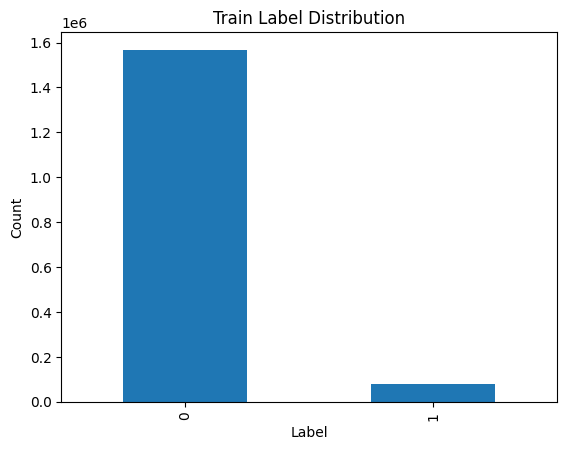

In [30]:
train_df_dedup["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

As we can see, the majority of the traffic in the dataset is normal traffic and the attack traffic is the minority. It is also close to the numbers we have learned about in class (90-10 split).

##Attack category distribution

In [31]:
print("Attack categories in train:")
display(train_df_dedup["attack_cat"].value_counts())

print("Attack category proportions in train:")
display(train_df_dedup["attack_cat"].value_counts(normalize=True))

Attack categories in train:


,count
attack_cat,
Normal,1567474
Exploits,22125
Generic,20246
Fuzzers,17455
Reconnaissance,10707
DoS,4547
Analysis,1741
Backdoor,1330
Shellcode,1197


Attack category proportions in train:


,proportion
attack_cat,
Normal,0.951606
Exploits,0.013432
Generic,0.012291
Fuzzers,0.010597
Reconnaissance,0.006500
DoS,0.002760
Analysis,0.001057
Backdoor,0.000807
Shellcode,0.000727


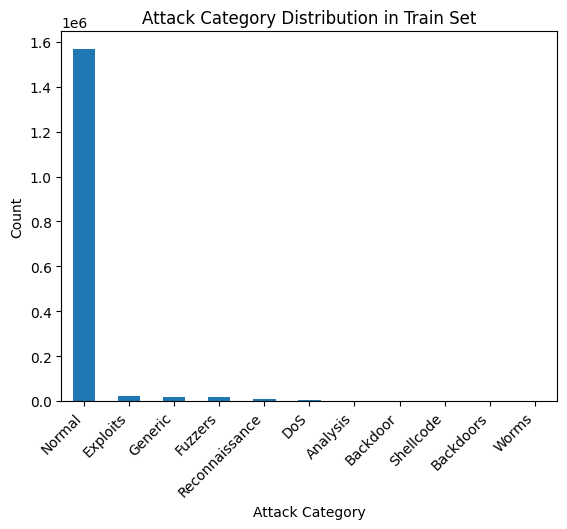

In [32]:
train_df_dedup["attack_cat"].value_counts().plot(kind="bar")
plt.title("Attack Category Distribution in Train Set")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

##Separate numeric and categorical columns

In [33]:
categorical_cols = train_df_dedup.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = train_df_dedup.select_dtypes(include=["int8","int16","int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['proto', 'state', 'service', 'attack_cat']
Numeric columns: ['srcip', 'sport', 'dstip', 'dsport', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'label']
Number of categorical columns: 4
Number of numeric columns: 45


##Categorical feature distributions

In [34]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(train_df_dedup[col].value_counts().head(20))


Column: proto


,count
proto,
tcp,1158527
udp,471009
arp,5104
unas,3783
ospf,3100
icmp,391
sctp,358
any,109
rsvp,74



Column: state


,count
state,
FIN,1146259
CON,435322
INT,59873
REQ,4766
RST,422
ECO,253
CLO,125
URH,79
ACC,30



Column: service


,count
service,
-,934744
dns,309781
http,162788
ftp-data,99818
smtp,64947
ssh,37453
ftp,36128
pop3,1191
ssl,115



Column: attack_cat


,count
attack_cat,
Normal,1567474
Exploits,22125
Generic,20246
Fuzzers,17455
Reconnaissance,10707
DoS,4547
Analysis,1741
Backdoor,1330
Shellcode,1197


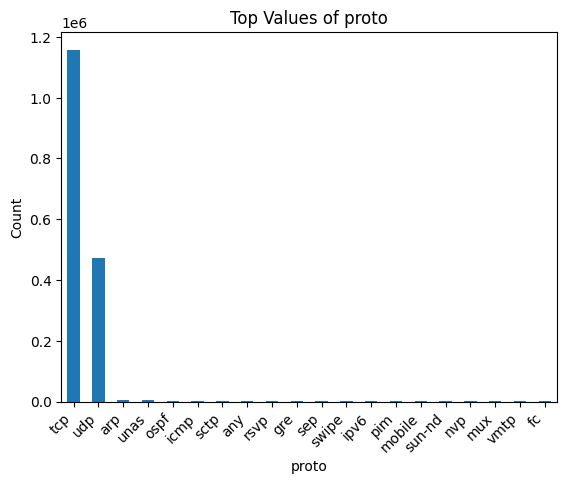

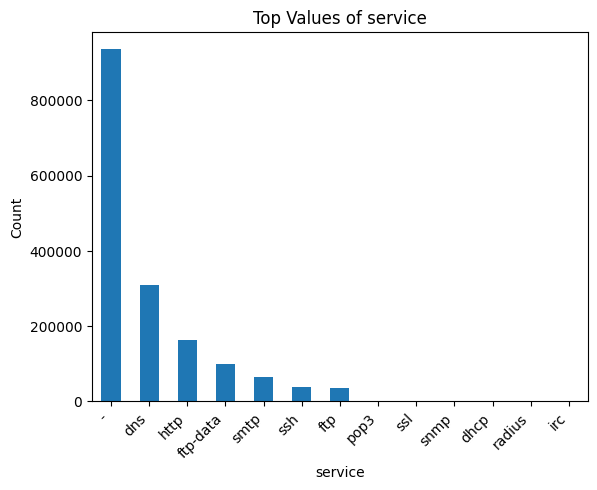

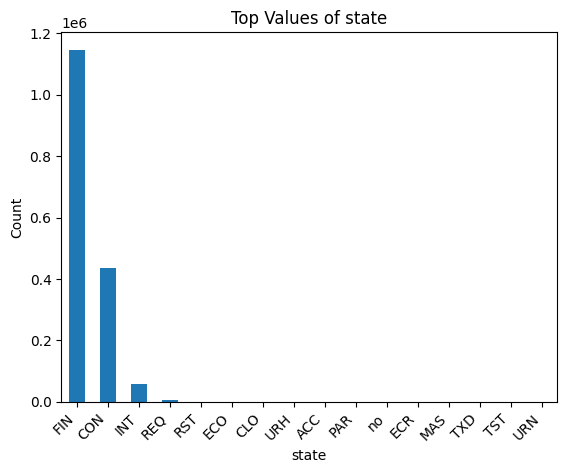

In [35]:
for col in ["proto", "service", "state"]:
    if col in train_df_dedup.columns:
        train_df_dedup[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Top Values of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.show()

##Numeric feature distributions

In [36]:
numeric_features_for_plots = [
    col for col in numeric_cols
    if col not in ["id", "label"]
]

print(numeric_features_for_plots[:20])

['srcip', 'sport', 'dstip', 'dsport', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz']


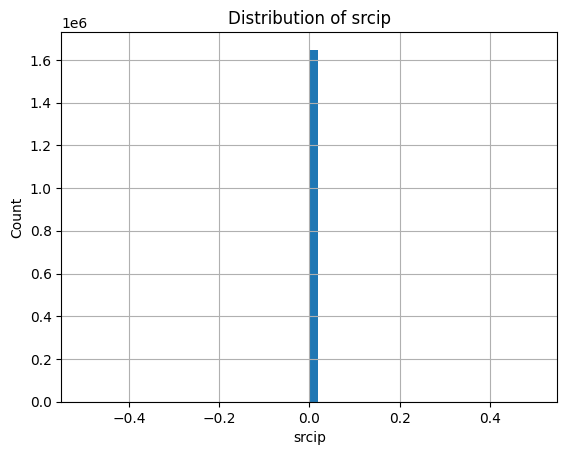

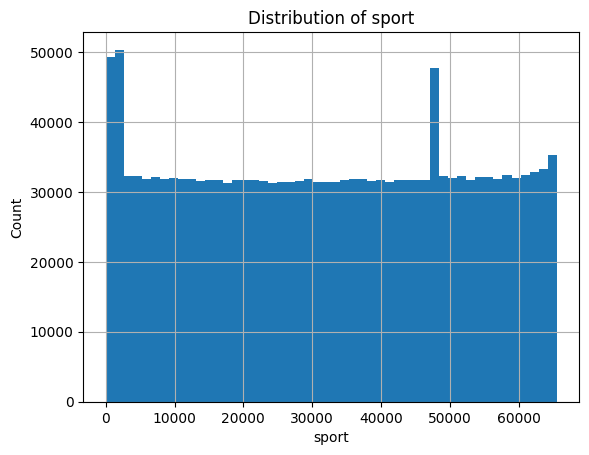

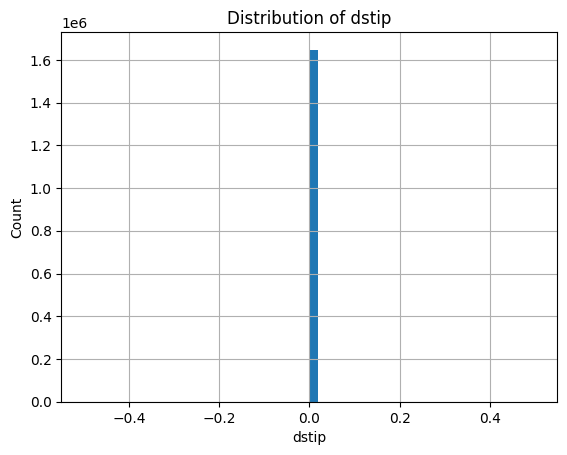

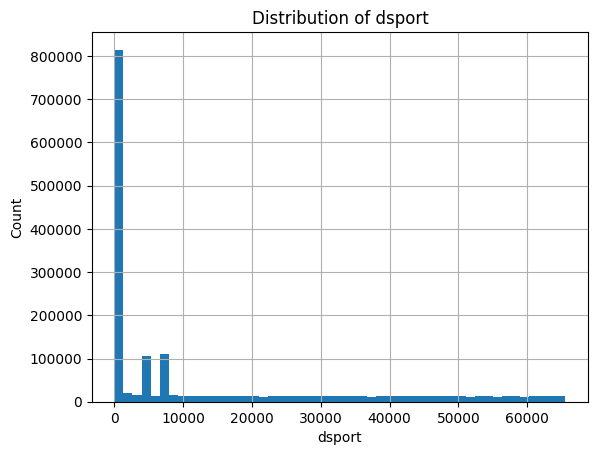

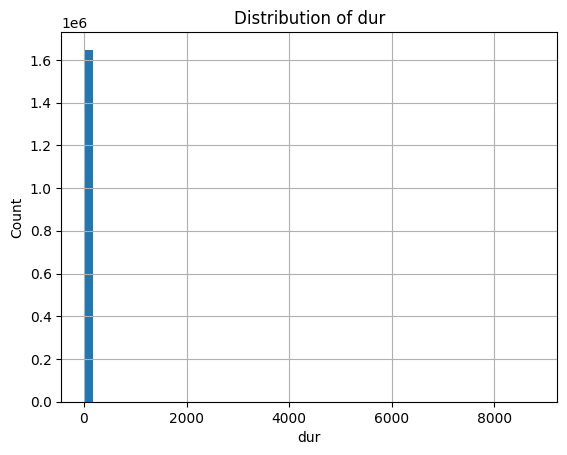

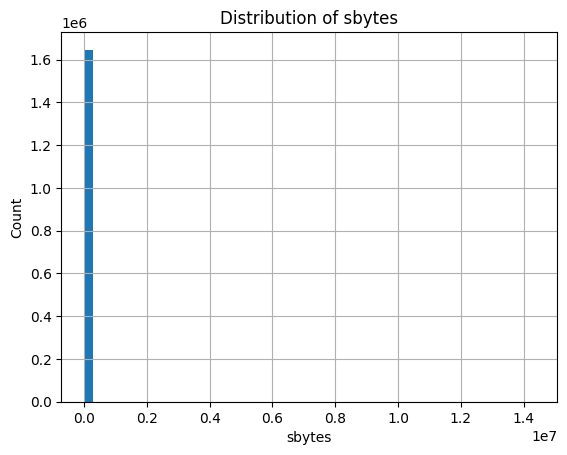

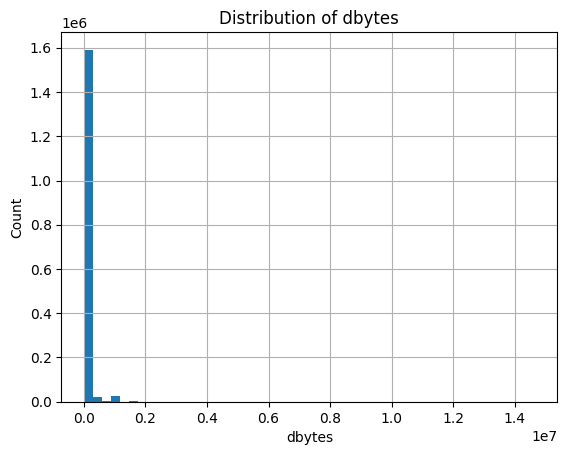

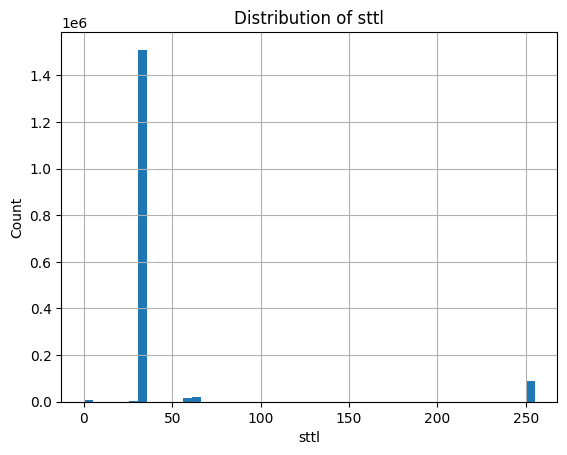

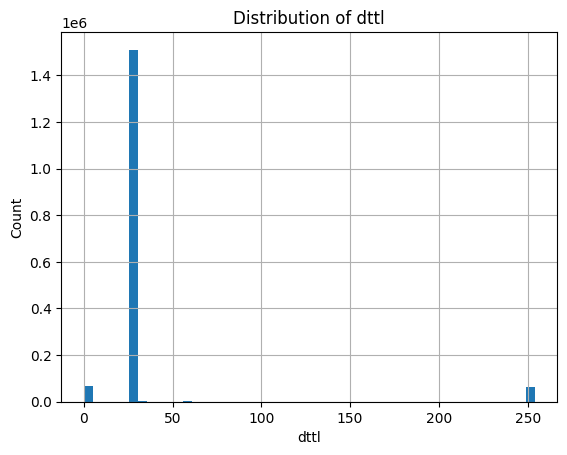

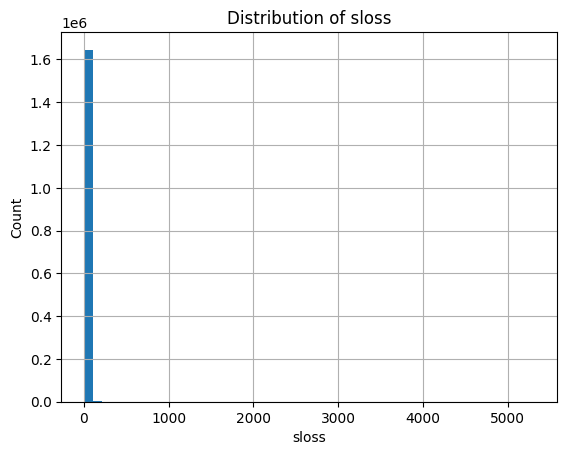

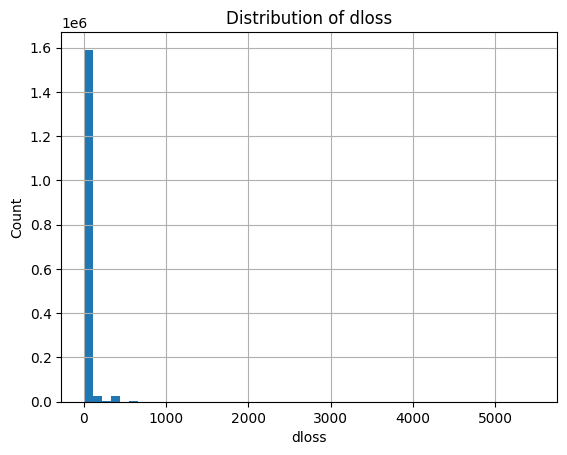

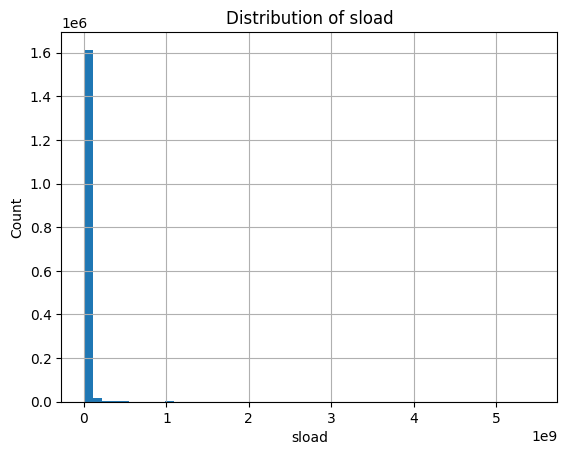

In [37]:
for col in numeric_features_for_plots[:12]:
    train_df_dedup[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

##Outlier Analysis

In [38]:
display(train_df_dedup[numeric_features_for_plots].describe().T)

,count,mean,std,min,25%,50%,75%,max
srcip,1647188.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
sport,1647188.0,3.236294e+04,1.933611e+04,0.000000e+00,1.543600e+04,3.255100e+04,4.892900e+04,6.553500e+04
dstip,1647188.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dsport,1647188.0,1.352145e+04,1.941025e+04,0.000000e+00,5.300000e+01,1.723000e+03,2.357925e+04,6.553500e+04
dur,1647188.0,6.473428e-01,1.014847e+01,0.000000e+00,3.537000e-03,2.635550e-02,3.337260e-01,8.786638e+03
sbytes,1647188.0,5.084055e+03,6.180576e+04,0.000000e+00,4.240000e+02,1.684000e+03,3.728000e+03,1.435577e+07
dbytes,1647188.0,4.197204e+04,1.700163e+05,0.000000e+00,3.040000e+02,3.080000e+03,1.991800e+04,1.465555e+07
sttl,1647188.0,4.359841e+01,5.051223e+01,0.000000e+00,3.100000e+01,3.100000e+01,3.100000e+01,2.550000e+02
dttl,1647188.0,3.652474e+01,4.373727e+01,0.000000e+00,2.900000e+01,2.900000e+01,2.900000e+01,2.540000e+02
sloss,1647188.0,6.107840e+00,2.447559e+01,0.000000e+00,0.000000e+00,4.000000e+00,7.000000e+00,5.319000e+03


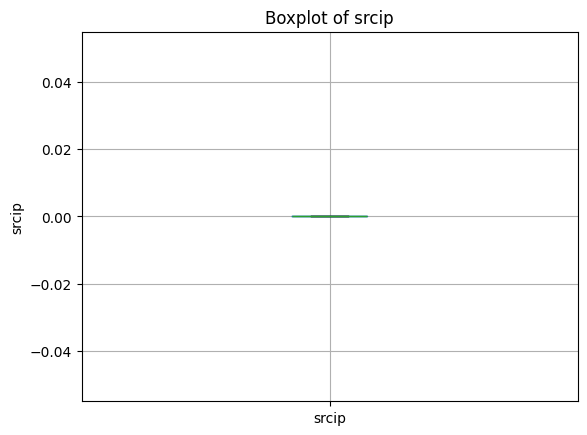

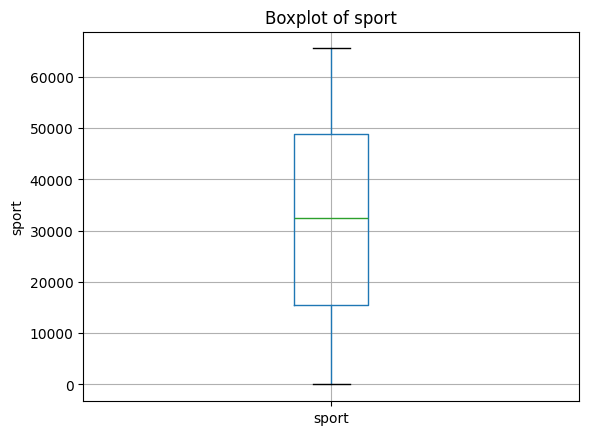

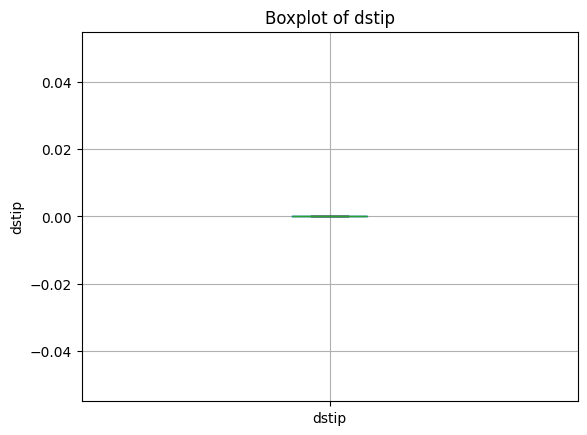

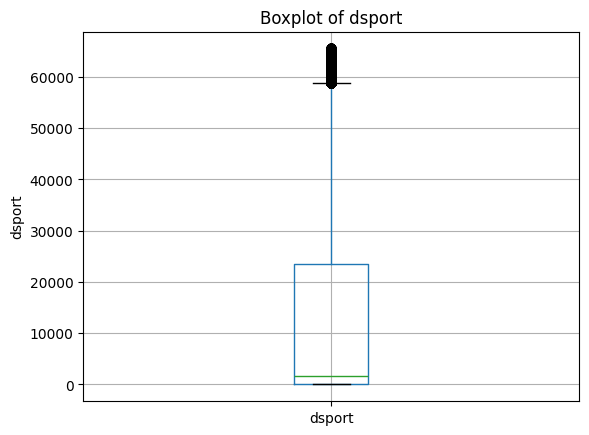

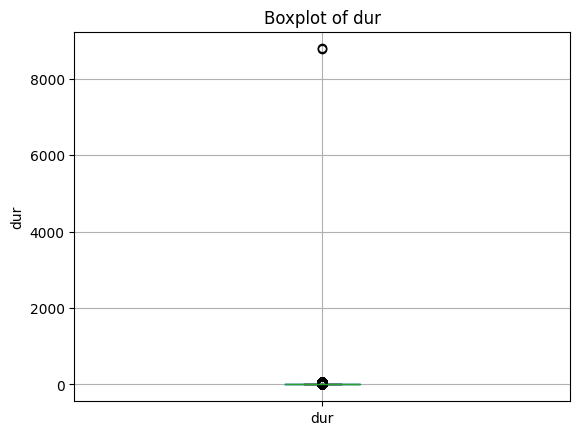

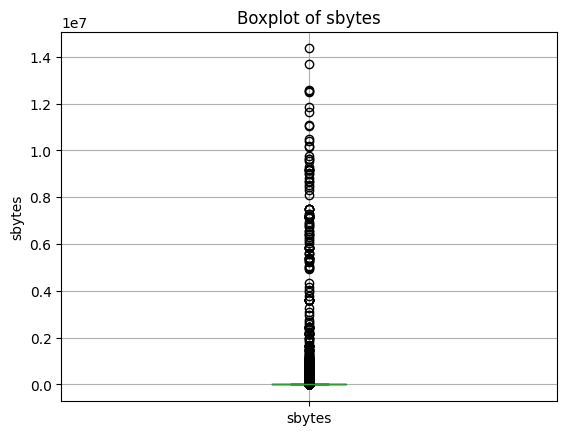

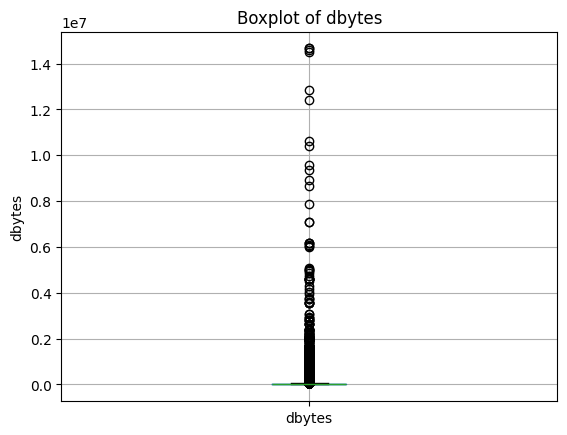

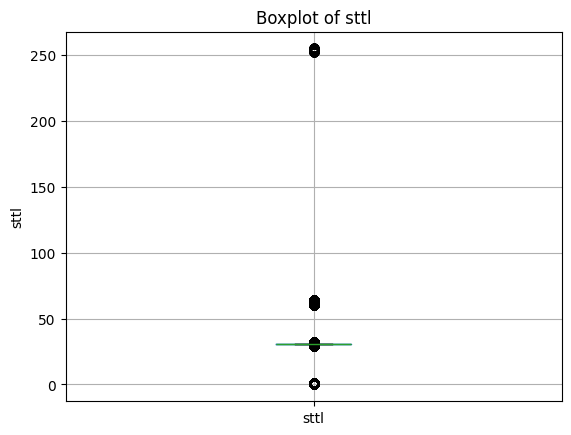

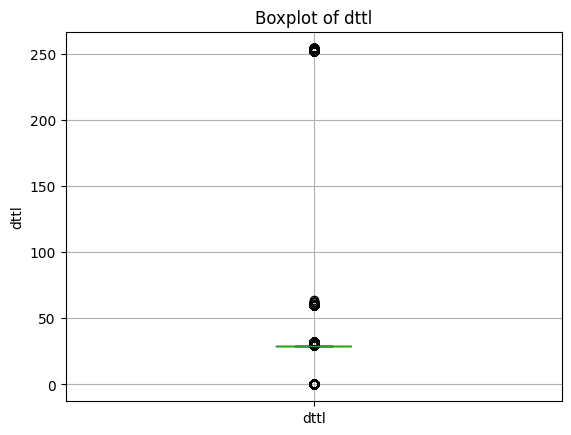

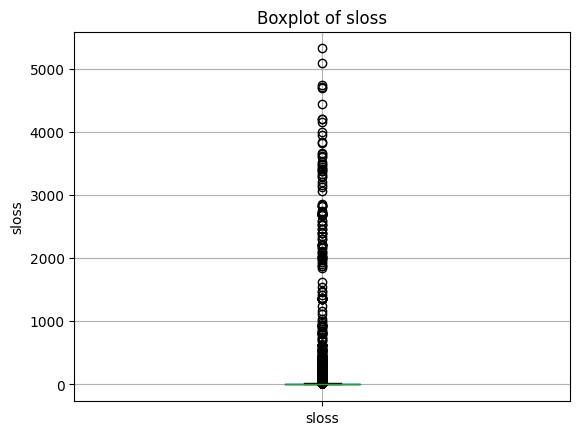

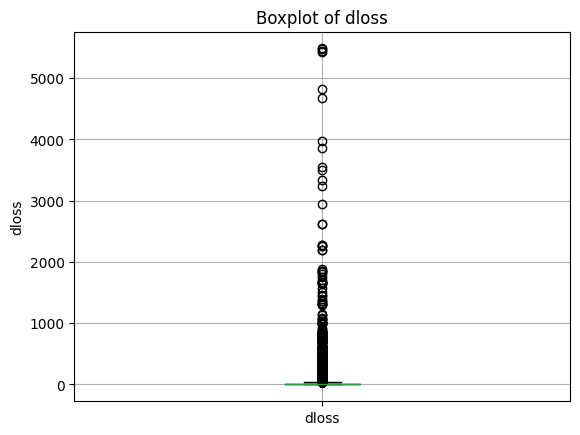

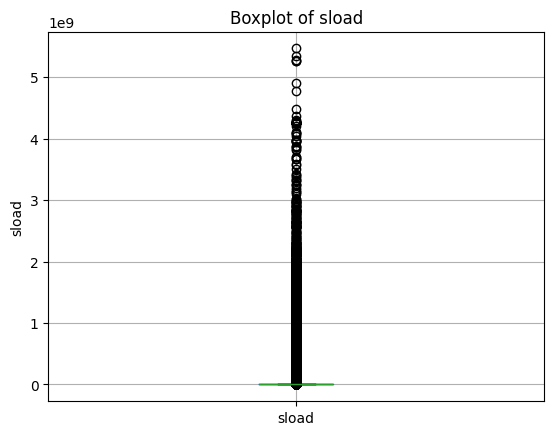

In [39]:
for col in numeric_features_for_plots[:12]:
    train_df_dedup.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

##Compare normal vs attack traffic

In [40]:
grouped_means = train_df_dedup.groupby("label")[numeric_features_for_plots].mean().T

display(grouped_means.head(30))

label,0,1
srcip,0.000000e+00,0.000000e+00
sport,3.259737e+04,2.775329e+04
dstip,0.000000e+00,0.000000e+00
dsport,1.412263e+04,1.700029e+03
dur,6.123396e-01,1.335637e+00
sbytes,4.455626e+03,1.744131e+04
dbytes,4.340968e+04,1.370269e+04
sttl,3.487676e+01,2.150984e+02
dttl,3.136159e+01,1.380514e+02
sloss,6.011759e+00,7.997140e+00


In [41]:
grouped_means["absolute_difference"] = (
    grouped_means[1] - grouped_means[0]
).abs()

display(grouped_means.sort_values("absolute_difference", ascending=False).head(20))

label,0,1,absolute_difference
dtcpb,1.525082e+09,1.168259e+09,3.568235e+08
stcpb,1.525203e+09,1.175676e+09,3.495274e+08
sload,5.307240e+06,8.220056e+07,7.689332e+07
dload,3.103812e+06,3.592317e+04,3.067889e+06
ltime,1.423062e+09,1.423910e+09,8.481258e+05
stime,1.423062e+09,1.423910e+09,8.481251e+05
dbytes,4.340968e+04,1.370269e+04,2.970699e+04
sbytes,4.455626e+03,1.744131e+04,1.298568e+04
dsport,1.412263e+04,1.700029e+03,1.242260e+04
sport,3.259737e+04,2.775329e+04,4.844070e+03


##Crosstab categorical features vs label

In [42]:
for col in ["proto", "service", "state"]:
    if col in train_df_dedup.columns:
        print(f"\nCrosstab: {col} vs label")
        ct = pd.crosstab(train_df_dedup[col], train_df_dedup["label"], normalize="index")
        display(ct.sort_values(by=1, ascending=False).head(20))


Crosstab: proto vs label


label,0,1
proto,,
3pc,0.0,1.0
a/n,0.0,1.0
aes-sp3-d,0.0,1.0
any,0.0,1.0
argus,0.0,1.0
aris,0.0,1.0
ax.25,0.0,1.0
xnet,0.0,1.0
bbn-rcc,0.0,1.0



Crosstab: service vs label


label,0,1
service,,
dhcp,0.000000,1.000000
ssl,0.000000,1.000000
pop3,0.003359,0.996641
snmp,0.011111,0.988889
irc,0.040000,0.960000
radius,0.321429,0.678571
http,0.910000,0.090000
smtp,0.939812,0.060188
dns,0.947301,0.052699



Crosstab: state vs label


label,0,1
state,,
INT,0.409032,0.590968
REQ,0.933068,0.066932
FIN,0.962247,0.037753
ACC,0.966667,0.033333
RST,0.973934,0.026066
CLO,0.992000,0.008000
CON,0.998337,0.001663
ECO,1.000000,0.000000
MAS,1.000000,0.000000


##Correlation analysis

In [43]:
corr_cols = [
    col for col in numeric_features_for_plots
    if col in train_df_dedup.columns
]

spearman_corr = train_df_dedup[corr_cols + ["label"]].corr(method="spearman")

label_corr = spearman_corr["label"].drop("label").sort_values(key=abs, ascending=False)

display(label_corr.head(20))

,label
ct_state_ttl,0.838260
sttl,0.756312
dload,-0.333322
dmeansz,-0.257686
ct_dst_sport_ltm,0.256875
dbytes,-0.210526
dpkts,-0.200257
dloss,-0.155388
spkts,-0.150745
dsport,-0.145068


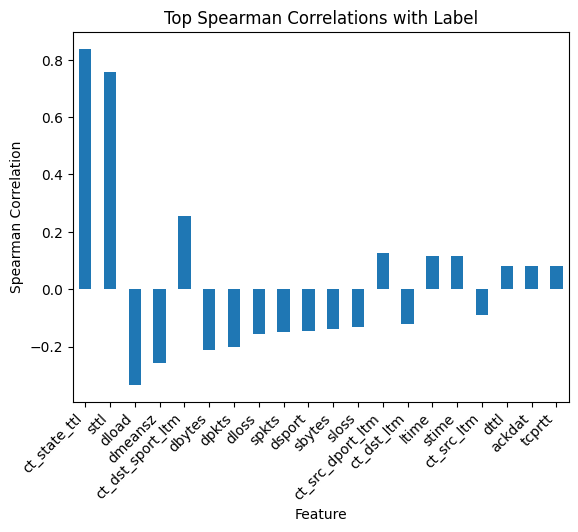

In [44]:
label_corr.head(20).plot(kind="bar")
plt.title("Top Spearman Correlations with Label")
plt.xlabel("Feature")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.show()

In [45]:
corr_matrix = train_df_dedup[corr_cols].corr(method="spearman").abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_spearman_corr"]

display(high_corr_pairs.head(30))

,feature_1,feature_2,abs_spearman_corr
0,stime,ltime,1.000000
1,trans_depth,ct_flw_http_mthd,0.999716
2,is_ftp_login,ct_ftp_cmd,0.998838
3,swin,dwin,0.996508
4,dloss,dpkts,0.982456
5,spkts,dpkts,0.980711
6,tcprtt,synack,0.972506
7,dloss,spkts,0.965932
8,sintpkt,dintpkt,0.948162
9,res_bdy_len,ct_flw_http_mthd,0.947786


##Temporal Analysis

In [46]:
possible_time_cols = [
    col for col in train_df_dedup.columns
    if "time" in col.lower() or "date" in col.lower() or "stamp" in col.lower()
]

print("Possible temporal columns:", possible_time_cols)

Possible temporal columns: ['stime', 'ltime']


The available preprocessed train/test version does not include explicit timestamp columns, so temporal ordering and time-based drift could not be directly analyzed.

#Feature Engineering

##Defining target and removing leakage columns

In [47]:
from math import nan
import gc

target_col = "label"

leakage_or_irrelevant_cols = []

if "attack_cat" in train_df_dedup.columns:
    leakage_or_irrelevant_cols.append("attack_cat")

if "id" in train_df_dedup.columns:
    leakage_or_irrelevant_cols.append("id")

print("Columns removed from features:", leakage_or_irrelevant_cols)

X_train = train_df_dedup.drop(columns=[target_col] + leakage_or_irrelevant_cols)
y_train = train_df_dedup[target_col].astype(int)

X_test = test_df_dedup.drop(columns=[target_col] + leakage_or_irrelevant_cols)
y_test = test_df_dedup[target_col].astype(int)

print("NaN values in train:", int(train_df_dedup.isna().sum().sum()))
print("NaN values in test:", int(test_df_dedup.isna().sum().sum()))

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Free train_df_dedup after creating X_train/y_train.
# Keep test_df_dedup because it is used later for error analysis.
del train_df_dedup
gc.collect()

Columns removed from features: ['attack_cat']
NaN values in train: 0
NaN values in test: 0
X_train: (1647188, 47)
X_test: (411797, 47)
y_train: (1647188,)
y_test: (411797,)


42372

In [48]:
print("NaNs in X_train:")
display(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nNaNs in X_test:")
display(X_test.isna().sum()[X_test.isna().sum() > 0])

NaNs in X_train:


,0



NaNs in X_test:


,0


The column attack_cat was excluded because it represents the attack category and would leak information when predicting the binary label. The id column was excluded because it is an identifier and has no cybersecurity meaning, but there is no such column so there was no need to worry.

##Separating numeric and categorical features

In [49]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int8","int16","int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['proto', 'state', 'service']
Numeric columns: ['srcip', 'sport', 'dstip', 'dsport', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
Number of categorical columns: 3
Number of numeric columns: 44


##Checking skewed numeric features

In [50]:
skewness = X_train[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)

display(skewness.head(20))
display(skewness.tail(20))

,0
dur,780.933533
trans_depth,158.499927
sbytes,132.357696
sloss,112.498109
djit,83.966590
sjit,57.771586
ackdat,40.462440
synack,38.478954
tcprtt,31.206274
is_sm_ips_ports,29.079740


,0
ct_state_ttl,6.092607
ct_dst_ltm,4.828146
dttl,4.619266
ct_src_ltm,4.013957
sttl,3.885552
smeansz,3.371515
ct_srv_dst,3.370119
ct_srv_src,3.088978
dload,1.678822
dsport,1.298225


In [51]:
skew_threshold = 1.0

log_transform_cols = [
    col for col in numeric_cols
    if abs(X_train[col].skew()) > skew_threshold and X_train[col].min() >= 0
]

regular_numeric_cols = [
    col for col in numeric_cols
    if col not in log_transform_cols
]

print("Log-transform columns:", log_transform_cols)
print("Regular numeric columns:", regular_numeric_cols)

Log-transform columns: ['dsport', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']
Regular numeric columns: ['srcip', 'sport', 'dstip', 'swin', 'dwin', 'stcpb', 'dtcpb', 'stime', 'ltime']


A log1p transformation reduces the effect of extreme large values while preserving zero values. This is useful for network traffic features, where unusually large values may dominate distance-based or linear models.

##Build preprocessing pipeline

In [52]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

log_numeric_pipeline = Pipeline(
    steps=[
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        # with_mean=False keeps the final transformed matrix sparse-friendly.
        ("scaler", StandardScaler(with_mean=False))
    ]
)

regular_numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_numeric_pipeline, log_transform_cols),
        ("num", regular_numeric_pipeline, regular_numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    sparse_threshold=1.0
)

##Redundency Analysis

In [53]:
corr_matrix = X_train[numeric_cols].corr(method="spearman").abs()
print("The correlation matrix determinant: ",np.linalg.det(corr_matrix))

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_spearman_corr"]

display(high_corr_pairs.head(30))

The correlation matrix determinant:  nan


/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


,feature_1,feature_2,abs_spearman_corr
0,stime,ltime,1.000000
1,trans_depth,ct_flw_http_mthd,0.999716
2,is_ftp_login,ct_ftp_cmd,0.998838
3,swin,dwin,0.996508
4,dloss,dpkts,0.982456
5,spkts,dpkts,0.980711
6,tcprtt,synack,0.972506
7,dloss,spkts,0.965932
8,sintpkt,dintpkt,0.948162
9,res_bdy_len,ct_flw_http_mthd,0.947786


In [54]:
correlation_threshold = 0.98

features_to_drop_due_to_corr = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

print("Highly correlated features to consider dropping:")
print(features_to_drop_due_to_corr)

Highly correlated features to consider dropping:
['dpkts', 'dwin', 'ltime', 'ct_flw_http_mthd', 'ct_ftp_cmd']


Several features are highly correlated, suggesting possible redundancy. However, I kept them for the baseline models and later compared this with a reduced-feature version.

#Model Training

##Importing model-training tools

In [55]:
import time
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

##Defining the models

In [56]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", LogisticRegression(
                solver="saga",
                max_iter=5000,
                tol=1e-3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                verbose=0
            ))
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=9,
                min_samples_split=6,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )
}

Logistic Regression gives a simple interpretable baseline.

Decision Tree can model nonlinear relationships and interactions between network-traffic features.

##Training the models

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.exceptions import ConvergenceWarning
import warnings
import numpy as np
import time

LOG_REG_MAX_ITER = 5000

log_reg_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(
            solver="saga",
            penalty="l2",
            max_iter=LOG_REG_MAX_ITER,
            tol=1e-3,
            class_weight="balanced",
            random_state=42,
            # Keep this at 1 to avoid excessive RAM use in Colab.
            n_jobs=1,
            verbose=0
        ))
    ]
)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    print("Training Logistic Regression...")
    start_time = time.time()
    log_reg_model.fit(X_train, y_train)
    end_time = time.time()
    print("Training completed.")
    print(f"Training time: {end_time - start_time:.2f} seconds\n")

    convergence_warnings = [
        warning for warning in caught_warnings
        if issubclass(warning.category, ConvergenceWarning)
    ]

log_reg_estimator = log_reg_model.named_steps["model"]
n_iter_used = int(log_reg_estimator.n_iter_[0])

print("Logistic Regression iterations used:", n_iter_used)
print("Maximum allowed iterations:", LOG_REG_MAX_ITER)

if len(convergence_warnings) == 0 and n_iter_used < LOG_REG_MAX_ITER:
    print("Convergence status: converged")
else:
    print("Convergence status: NOT fully converged")
    print("Recommendation: increase max_iter or loosen tol slightly.")

Training Logistic Regression...
Training completed.
Training time: 377.38 seconds

Logistic Regression iterations used: 220
Maximum allowed iterations: 5000
Convergence status: converged


In [58]:
trained_models = {}
training_times = {}

for model_name, model in models.items():
    if model_name == "Logistic Regression":#already trained
        trained_models[model_name] = log_reg_model
        training_times[model_name] = end_time - start_time
        continue
    print(f"Training {model_name}...")

    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    trained_models[model_name] = model
    training_times[model_name] = end_time - start_time

    print(f"{model_name} trained in {training_times[model_name]:.2f} seconds\n")

Training Decision Tree...
Decision Tree trained in 32.39 seconds



###Cross Validation

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    fbeta_score,
    matthews_corrcoef
)
import pandas as pd
import numpy as np

# 3-fold CV is used instead of 5-fold to keep the full-dataset experiment runnable
# in Colab RAM. The professor requested mean/std; 3 folds are sufficient for that.
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "mcc": make_scorer(matthews_corrcoef),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_models = {
    "Logistic Regression": log_reg_model,
    "Decision Tree": models["Decision Tree"]
}

cv_results = []

for model_name, model in cv_models.items():
    print(f"Running 3-fold cross-validation for {model_name}...")

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        # Critical RAM fix: do not run folds in parallel, because each fold
        # can make its own transformed design matrix copy.
        n_jobs=1,
        pre_dispatch=1,
        return_train_score=False
    )

    row = {
        "model": model_name,
        "fit_time_mean": np.mean(scores["fit_time"]),
        "fit_time_std": np.std(scores["fit_time"]),
        "score_time_mean": np.mean(scores["score_time"]),
        "score_time_std": np.std(scores["score_time"]),
        "f2_mean": np.mean(scores["test_f2"]),
        "f2_std": np.std(scores["test_f2"]),
        "mcc_mean": np.mean(scores["test_mcc"]),
        "mcc_std": np.std(scores["test_mcc"]),
        "roc_auc_mean": np.mean(scores["test_roc_auc"]),
        "roc_auc_std": np.std(scores["test_roc_auc"]),
        "average_precision_mean": np.mean(scores["test_average_precision"]),
        "average_precision_std": np.std(scores["test_average_precision"]),
    }

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

Running 3-fold cross-validation for Logistic Regression...
Running 3-fold cross-validation for Decision Tree...


,model,fit_time_mean,fit_time_std,score_time_mean,score_time_std,f2_mean,f2_std,mcc_mean,mcc_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,Logistic Regression,259.521183,3.822881,2.778943,0.129304,0.922132,0.009261,0.830536,0.017214,0.994069,0.000029,0.824066,0.001075
1,Decision Tree,20.332353,0.324190,2.601919,0.050348,0.945187,0.000105,0.874750,0.000216,0.998626,0.000119,0.973370,0.000906


In [60]:
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

cv_results_df.to_csv("results/cross_validation_results.csv", index=False)

print("Saved cross-validation results to results/cross_validation_results.csv")

Saved cross-validation results to results/cross_validation_results.csv


Due to the size of the full UNSW-NB15 dataset and Colab memory limits, stratified 3-fold cross-validation was used. The folds were evaluated sequentially to avoid duplicating large transformed feature matrices in memory.

### Cross-Validation and Logistic Regression Convergence

To address convergence concerns, Logistic Regression was trained with an increased `max_iter` value and the number of iterations used by the solver was explicitly checked. The model was considered converged only if no `ConvergenceWarning` was raised and the solver stopped before reaching the maximum number of iterations.

In addition to the final train/test evaluation, I performed stratified 3-fold cross-validation on the training set. The reported metrics are F2, MCC, ROC-AUC, and Average Precision, including both mean and standard deviation across folds. F2 was included because recall is especially important in intrusion detection, while MCC is useful for imbalanced classification. ROC-AUC and Average Precision evaluate ranking quality across thresholds.

##Quick performance check

In [84]:
quick_results = []

for model_name, model in trained_models.items():
    print(f"Evaluating {model_name}...")

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = None

    quick_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "roc_auc": roc_auc,
        "training_time_seconds": training_times[model_name]
    })

quick_results_df = pd.DataFrame(quick_results)
display(quick_results_df)

Evaluating Logistic Regression...
Evaluating Decision Tree...


,model,accuracy,precision,recall,f1,mcc,roc_auc,training_time_seconds
0,Logistic Regression,0.981430,0.723114,0.998695,0.838851,0.841452,0.994881,377.379685
1,Decision Tree,0.985935,0.775050,0.999448,0.873060,0.873590,0.998694,32.387103


##Saving the trained models

In [85]:
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

for model_name, model in trained_models.items():
    file_name = model_name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(model, models_dir / file_name)

print("Saved models:")
for path in models_dir.glob("*.joblib"):
    print(path)

Saved models:
models/decision_tree.joblib
models/logistic_regression.joblib


#Evaluation

##Defining Evaluation Function

In [86]:
def evaluate_binary_classifier(model_name, model, X_test, y_test):
    """
    Evaluate a binary classifier on the test set.
    Returns a dictionary of metrics and prediction arrays.
    """

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
    }

    return metrics, y_pred, y_score

##Evaluating all trained models

In [87]:
evaluation_results = {}
prediction_outputs = {}

for model_name, model in trained_models.items():
    print(f"Evaluating {model_name}...")

    metrics, y_pred, y_score = evaluate_binary_classifier(
        model_name,
        model,
        X_test,
        y_test
    )

    evaluation_results[model_name] = metrics

    prediction_outputs[model_name] = {
        "y_pred": y_pred,
        "y_score": y_score
    }

evaluation_results_df = pd.DataFrame(evaluation_results.values())

display(evaluation_results_df)

Evaluating Logistic Regression...
Evaluating Decision Tree...


,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate
0,Logistic Regression,0.981430,0.989624,0.723114,0.998695,0.838851,0.927965,0.841452,0.994881,0.851777,384247,7621,26,19903,0.019448,0.001305
1,Decision Tree,0.985935,0.992348,0.775050,0.999448,0.873060,0.944742,0.873590,0.998694,0.973239,386087,5781,11,19918,0.014752,0.000552


##Classification Reports

In [88]:
for model_name, model in trained_models.items():
    y_pred = prediction_outputs[model_name]["y_pred"]

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    391868
      Attack       0.72      1.00      0.84     19929

    accuracy                           0.98    411797
   macro avg       0.86      0.99      0.91    411797
weighted avg       0.99      0.98      0.98    411797

Decision Tree
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    391868
      Attack       0.78      1.00      0.87     19929

    accuracy                           0.99    411797
   macro avg       0.89      0.99      0.93    411797
weighted avg       0.99      0.99      0.99    411797



##Confusion matrices

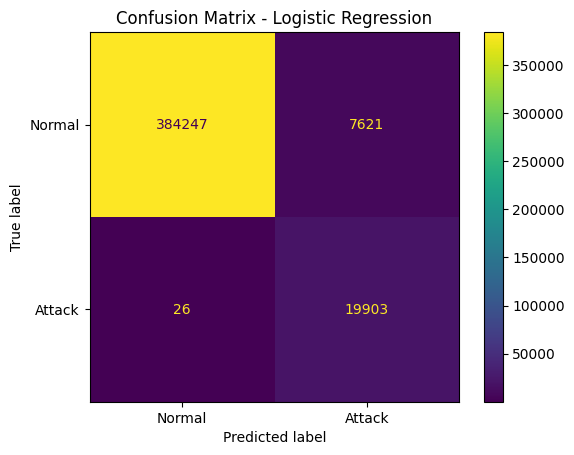

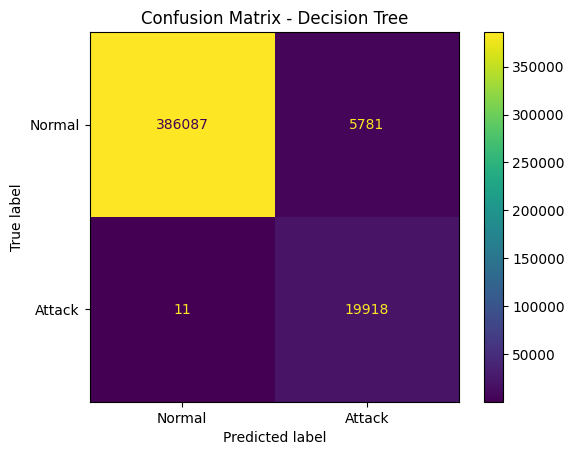

In [89]:
for model_name, model in trained_models.items():
    y_pred = prediction_outputs[model_name]["y_pred"]

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Attack"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

##ROC curves

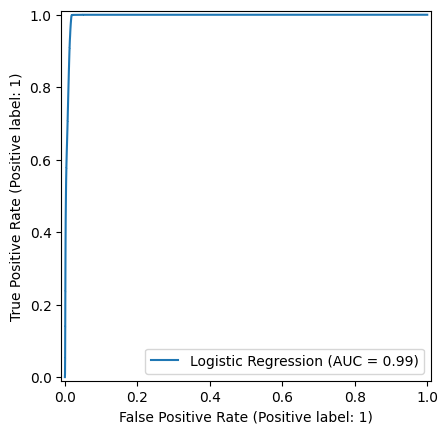

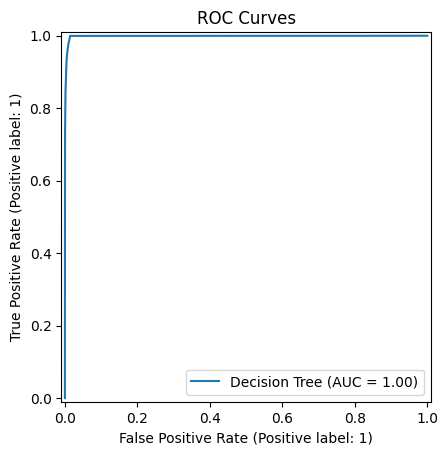

In [90]:
for model_name, model in trained_models.items():
    y_score = prediction_outputs[model_name]["y_score"]

    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name
    )

plt.title("ROC Curves")
plt.show()

##Precision-recall curves

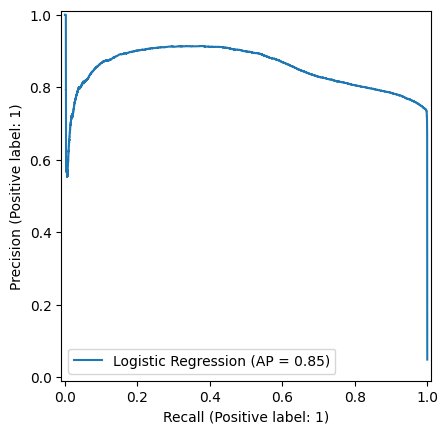

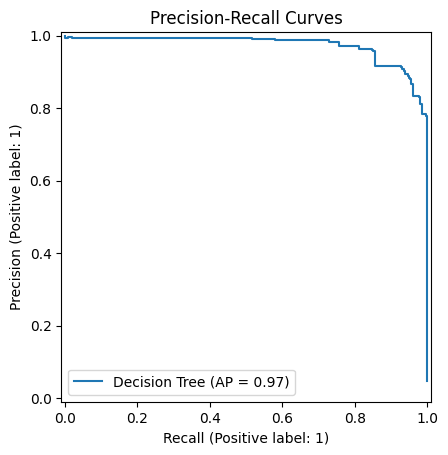

In [91]:
for model_name, model in trained_models.items():
    y_score = prediction_outputs[model_name]["y_score"]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name
    )

plt.title("Precision-Recall Curves")
plt.show()

##Choosing the best model

In [92]:
evaluation_results_df.sort_values(
    by=["f2", "mcc", "f1"],
    ascending=False
)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate
1,Decision Tree,0.985935,0.992348,0.775050,0.999448,0.873060,0.944742,0.873590,0.998694,0.973239,386087,5781,11,19918,0.014752,0.000552
0,Logistic Regression,0.981430,0.989624,0.723114,0.998695,0.838851,0.927965,0.841452,0.994881,0.851777,384247,7621,26,19903,0.019448,0.001305


In [93]:
best_model_name = evaluation_results_df.sort_values(
    by=["f2", "mcc", "f1"],
    ascending=False
).iloc[0]["model"]

best_model = trained_models[best_model_name]

print("Selected best model:", best_model_name)

Selected best model: Decision Tree


##Evaluation Summary

The models were evaluated using accuracy, balanced accuracy, precision, recall, F1 score, F2 score, MCC, ROC-AUC, average precision, and the confusion matrix.

Accuracy alone is not sufficient for intrusion detection because the cost of false positives and false negatives is asymmetric. A false positive means normal traffic is incorrectly flagged as malicious, which can overload security analysts. A false negative means malicious traffic is classified as normal, which is usually more dangerous because an attack may go undetected.

For this reason, recall, F2 score, MCC, false positive rate, and false negative rate were emphasized in the evaluation.

#Error Analysis

##Building error-analysis dataframe

In [94]:
y_pred_best = prediction_outputs[best_model_name]["y_pred"]
y_score_best = prediction_outputs[best_model_name]["y_score"]

error_df = test_df_dedup.copy()

error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred_best
error_df["attack_probability"] = y_score_best

def classify_error(row):
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "True Negative"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "False Positive"
    elif row["y_true"] == 1 and row["y_pred"] == 0:
        return "False Negative"
    elif row["y_true"] == 1 and row["y_pred"] == 1:
        return "True Positive"

error_df["prediction_type"] = error_df.apply(classify_error, axis=1)

display(error_df[["y_true", "y_pred", "attack_probability", "prediction_type"]].head())

,y_true,y_pred,attack_probability,prediction_type
0,0,0,0.0,True Negative
1,0,0,0.0,True Negative
2,0,0,0.0,True Negative
3,0,0,0.0,True Negative
4,0,0,0.0,True Negative


##Count prediction types

,count
prediction_type,
True Negative,386087
True Positive,19918
False Positive,5781
False Negative,11


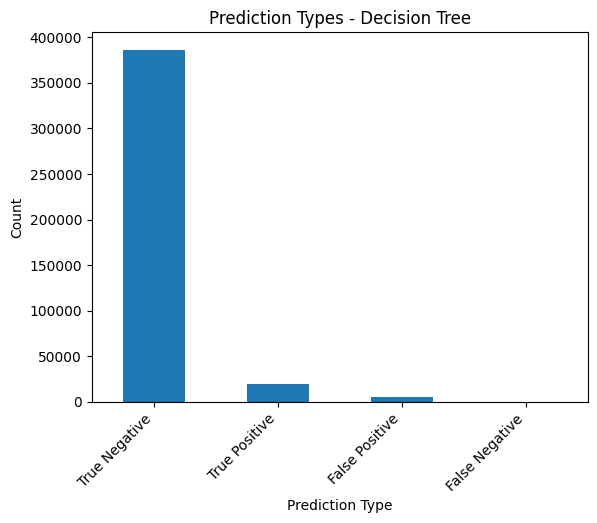

In [95]:
error_counts = error_df["prediction_type"].value_counts()
display(error_counts)

error_counts.plot(kind="bar")
plt.title(f"Prediction Types - {best_model_name}")
plt.xlabel("Prediction Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

##Analysing False Positives

In [96]:
false_positives = error_df[error_df["prediction_type"] == "False Positive"]

print("Number of false positives:", len(false_positives))
display(false_positives.head())

Number of false positives: 5781


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,y_true,y_pred,attack_probability,prediction_type
25,0.0,65037.0,0.0,80.0,tcp,FIN,0.808557,838,1186,62,252,2,2,http,7.470098e+03,10270.148438,10,8,255,255,3561323379,4257217453,84,148,0,0,5786.090321,209.756313,1424233375,1424233376,89.839667,111.522711,0.062039,0.027063,0.034976,0,1,0.0,0.0,0.0,2,2,2,20,1,1,3,Normal,0,0,1,0.828427,False Positive
42,0.0,44874.0,0.0,80.0,tcp,FIN,1.403470,68187,698,254,252,27,1,-,3.822012e+05,3733.603027,60,16,255,255,477743960,4035443728,1136,44,0,0,2529.256345,100.824883,1421928114,1421928116,23.346203,88.283867,0.165872,0.079211,0.086661,0,1,0.0,0.0,0.0,2,2,1,1,1,1,1,Normal,0,0,1,0.987424,False Positive
56,0.0,8017.0,0.0,135.0,tcp,FIN,0.430162,588,268,254,252,2,1,-,9.856751e+03,4165.872070,10,6,255,255,481650357,3852581308,59,45,0,0,2384.212031,118.338039,1424230928,1424230928,44.483444,76.229203,0.163803,0.049010,0.114793,0,1,0.0,0.0,0.0,2,2,2,24,2,2,2,Normal,0,0,1,0.945784,False Positive
124,0.0,7808.0,0.0,520.0,udp,INT,0.000010,1064,0,254,0,0,0,-,4.256000e+08,0.000000,2,0,0,0,0,0,532,0,0,0,0.000000,0.000000,1424229651,1424229651,0.010000,0.000000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,35,36,17,17,17,1,35,Normal,0,0,1,0.765730,False Positive
247,0.0,29189.0,0.0,179.0,tcp,FIN,0.913601,924,678,254,252,4,4,-,7.513127e+03,5446.579102,14,12,255,255,1474526434,1385236360,66,57,0,0,3457.891129,107.316930,1424222939,1424222939,70.206536,75.055000,0.178134,0.087991,0.090143,0,1,0.0,0.0,0.0,6,4,2,3,2,2,4,Normal,0,0,1,0.891784,False Positive


In [97]:
display(
    false_positives.sort_values(
        by="attack_probability",
        ascending=False
    ).head(20)
)

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,y_true,y_pred,attack_probability,prediction_type
237454,0.0,52222.0,0.0,520.0,udp,INT,0.000001,78,0,254,0,0,0,-,3.120000e+08,0.000000e+00,2,0,0,0,0,0,39,0,0,0,0.000000,0.000000,1424242392,1424242392,0.001000,0.000000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,1,1,1,1,1,1,1,Normal,0,0,1,1.000000,False Positive
120587,0.0,64854.0,0.0,21.0,tcp,FIN,0.518852,696,682,254,252,3,4,ftp,9.837102e+03,9.652078e+03,12,12,255,255,3489859772,3755251475,58,57,0,0,2268.854910,47.783547,1424237597,1424237597,47.168363,39.293184,0.111401,0.052407,0.058994,0,1,0.0,0.0,0.0,1,1,1,1,1,1,1,Normal,0,0,1,0.999656,False Positive
405108,0.0,17849.0,0.0,80.0,tcp,FIN,0.519983,866,22896,62,252,2,9,http,1.221578e+04,3.375803e+05,12,24,255,255,4070831055,76491978,72,954,1,10721,3325.246588,2548.418838,1424219063,1424219063,47.271183,20.692217,0.095227,0.026626,0.068601,0,1,1.0,0.0,0.0,6,3,1,1,1,1,1,Normal,0,0,1,0.999656,False Positive
34466,0.0,56555.0,0.0,80.0,tcp,FIN,0.398737,822,1222,62,252,2,2,-,1.484688e+04,2.146778e+04,10,8,255,255,576475633,3232960084,82,153,0,0,2261.411096,64.178055,1421932914,1421932914,44.304111,43.515145,0.088592,0.050173,0.038419,0,1,0.0,0.0,0.0,5,4,2,2,2,1,2,Normal,0,0,1,0.999656,False Positive
121311,0.0,9230.0,0.0,21.0,tcp,FIN,0.506881,586,682,254,252,3,4,ftp,8.491145e+03,9.880031e+03,12,12,255,255,1875404451,429244352,49,57,0,0,2281.882877,61.264652,1424223484,1424223485,46.080092,44.401090,0.064464,0.017736,0.046728,0,1,0.0,0.0,0.0,2,2,2,2,2,1,2,Normal,0,0,1,0.999656,False Positive
19563,0.0,5861.0,0.0,80.0,tcp,FIN,0.388844,834,1090,62,252,2,2,http,1.545093e+04,1.962741e+04,10,8,255,255,2926800185,3556222103,83,136,1,123,2078.677803,64.495617,1424253826,1424253826,43.204889,49.495145,0.082319,0.041698,0.040621,0,1,1.0,0.0,0.0,4,3,1,2,2,1,3,Normal,0,0,1,0.999656,False Positive
116090,0.0,30324.0,0.0,21.0,tcp,FIN,0.508592,586,682,254,252,3,4,ftp,8.462579e+03,9.846793e+03,12,12,255,255,2494558911,288983754,49,57,0,0,2318.682576,55.992277,1424258442,1424258443,46.235636,41.803816,0.076753,0.031421,0.045332,0,1,0.0,0.0,0.0,3,3,1,1,1,1,3,Normal,0,0,1,0.999656,False Positive
361872,0.0,37147.0,0.0,80.0,tcp,FIN,0.227228,1526,268,254,252,2,1,http,4.837432e+04,7.886352e+03,10,6,255,255,58818458,1164368772,153,45,1,0,1216.262525,57.458773,1424248472,1424248472,23.740444,39.148000,0.085653,0.031487,0.054166,0,1,1.0,0.0,0.0,9,10,3,3,3,1,10,Normal,0,0,1,0.999656,False Positive
182956,0.0,60991.0,0.0,21.0,tcp,FIN,0.444452,696,682,254,252,3,4,ftp,1.148380e+04,1.126781e+04,12,12,255,255,1392236319,909040787,58,57,0,0,2072.056112,55.112711,1424237597,1424237598,40.404729,38.200363,0.057616,0.023642,0.033974,0,1,0.0,0.0,0.0,2,2,2,2,2,1,2,Normal,0,0,1,0.999656,False Positive
43385,0.0,64951.0,0.0,80.0,tcp,FIN,0.374274,864,1364,62,252,2,2,http,1.662953e+04,2.552141e+04,10,8,255,255,3646470697,1627150465,86,171,1,258,2126.960293,81.833898,1424232952,1424232953,41.586000,47.155000,0.142307,0.035141,0.107166,0,1,1.0,0.0,0.0,4,3,1,1,1,1,3,Normal,0,0,1,0.999656,False Positive


The model seems to classify normal traffic as attack traffic with high certainty.

##Analysing False Negatives

In [98]:
false_negatives = error_df[error_df["prediction_type"] == "False Negative"]

print("Number of false negatives:", len(false_negatives))
display(false_negatives.head())

Number of false negatives: 11


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,y_true,y_pred,attack_probability,prediction_type
29646,0.0,65532.0,0.0,520.0,udp,INT,0.000004,1064,0,254,0,0,0,-,1.064000e+09,0.000000,2,0,0,0,0,0,532,0,0,0,0.000000,0.000000,1424250986,1424250986,0.004000,0.000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,22,22,6,6,6,2,22,Fuzzers,1,1,0,0.268763,False Negative
40562,0.0,39394.0,0.0,80.0,tcp,RST,0.092018,258,86,254,60,1,1,http,1.869199e+04,3738.398926,6,2,255,255,16616018,4193704849,43,43,1,0,1132.968293,0.000000,1424241240,1424241240,18.403600,0.007,0.079067,0.057724,0.021343,0,0,2.0,0.0,0.0,1,1,6,6,6,2,13,Reconnaissance,1,1,0,0.000000,False Negative
46156,0.0,8272.0,0.0,520.0,udp,INT,25.591019,2128,0,254,0,0,0,-,4.989250e+02,0.000000,4,0,0,0,0,0,532,0,0,0,12063.709000,0.000000,1424222585,1424222611,8530.339000,0.000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,22,22,6,6,6,1,22,Fuzzers,1,1,0,0.268763,False Negative
109716,0.0,64930.0,0.0,179.0,tcp,FIN,0.725222,550,354,254,252,2,1,-,5.460397e+03,3419.642578,10,8,255,255,756458129,1149536180,55,44,0,0,4164.024141,171.151797,1424220233,1424220234,76.432111,92.596,0.181819,0.077047,0.104772,0,1,0.0,0.0,0.0,3,3,1,2,1,1,3,Fuzzers,1,1,0,0.000000,False Negative
157194,0.0,39394.0,0.0,80.0,tcp,RST,0.092018,258,86,254,60,1,1,-,1.869199e+04,3738.398926,6,2,255,255,16616018,4193704849,43,43,1,0,1132.968293,0.000000,1424241240,1424241240,18.403600,0.007,0.079067,0.057724,0.021343,0,0,2.0,0.0,0.0,12,12,6,6,6,2,13,Reconnaissance,1,1,0,0.000000,False Negative


In [99]:
display(
    false_negatives.sort_values(
        by="attack_probability",
        ascending=True
    ).head(20)
)

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,y_true,y_pred,attack_probability,prediction_type
40562,0.0,39394.0,0.0,80.0,tcp,RST,0.092018,258,86,254,60,1,1,http,1.869199e+04,3738.398926,6,2,255,255,16616018,4193704849,43,43,1,0,1132.968293,0.000000,1424241240,1424241240,18.403600,0.007000,0.079067,0.057724,0.021343,0,0,2.0,0.0,0.0,1,1,6,6,6,2,13,Reconnaissance,1,1,0,0.000000,False Negative
109716,0.0,64930.0,0.0,179.0,tcp,FIN,0.725222,550,354,254,252,2,1,-,5.460397e+03,3419.642578,10,8,255,255,756458129,1149536180,55,44,0,0,4164.024141,171.151797,1424220233,1424220234,76.432111,92.596000,0.181819,0.077047,0.104772,0,1,0.0,0.0,0.0,3,3,1,2,1,1,3,Fuzzers,1,1,0,0.000000,False Negative
207904,0.0,36270.0,0.0,520.0,udp,INT,0.000034,78,0,254,0,0,0,-,9.176470e+06,0.000000,2,0,0,0,0,0,39,0,0,0,0.000000,0.000000,1424257031,1424257031,0.034000,0.000000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,21,21,4,4,4,1,21,Fuzzers,1,1,0,0.000000,False Negative
157194,0.0,39394.0,0.0,80.0,tcp,RST,0.092018,258,86,254,60,1,1,-,1.869199e+04,3738.398926,6,2,255,255,16616018,4193704849,43,43,1,0,1132.968293,0.000000,1424241240,1424241240,18.403600,0.007000,0.079067,0.057724,0.021343,0,0,2.0,0.0,0.0,12,12,6,6,6,2,13,Reconnaissance,1,1,0,0.000000,False Negative
209152,0.0,3203.0,0.0,3306.0,tcp,FIN,52.484825,1216,1292,254,252,4,7,-,1.762033e+02,187.177917,20,20,255,255,1166588329,874400930,61,65,0,0,367803.560200,11331.453000,1421931218,1421931270,2762.359105,2757.948750,0.129377,0.082733,0.046644,0,1,0.0,0.0,0.0,4,3,2,2,2,2,2,Exploits,1,1,0,0.000000,False Negative
310975,0.0,33019.0,0.0,139.0,tcp,ACC,0.012899,96,96,254,252,1,1,-,2.976975e+04,29769.750000,2,2,255,255,1089888449,423598219,48,48,0,0,0.000000,0.000000,1424223096,1424223096,0.005000,0.002000,0.012892,0.012892,0.000000,0,4,0.0,0.0,0.0,2,2,1,1,1,1,2,Exploits,1,1,0,0.000000,False Negative
377620,0.0,10821.0,0.0,445.0,tcp,FIN,56.306396,1244,536,254,252,5,1,-,1.679383e+02,69.903252,20,12,255,255,3530251799,2229703314,62,45,0,0,402968.301900,15949.830000,1421933715,1421933771,2961.553053,5112.051500,0.121496,0.073820,0.047676,0,1,0.0,0.0,0.0,5,5,2,2,2,1,2,Fuzzers,1,1,0,0.000000,False Negative
345940,0.0,60235.0,0.0,80.0,tcp,CON,0.500549,96,182,62,252,1,1,-,7.671577e+02,2189.595703,2,4,255,255,1131796587,3594767646,48,46,0,0,0.000000,202.287453,1421930931,1421930931,0.004000,143.042328,0.071418,0.071418,0.000000,0,3,0.0,0.0,0.0,8,2,1,2,1,1,1,DoS,1,1,0,0.000000,False Negative
380552,0.0,15509.0,0.0,520.0,udp,INT,0.000004,78,0,254,0,0,0,-,7.800000e+07,0.000000,2,0,0,0,0,0,39,0,0,0,0.000000,0.000000,1424256792,1424256792,0.004000,0.000000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,3,8,1,1,1,1,2,Fuzzers,1,1,0,0.000000,False Negative
46156,0.0,8272.0,0.0,520.0,udp,INT,25.591019,2128,0,254,0,0,0,-,4.989250e+02,0.000000,4,0,0,0,0,0,532,0,0,0,12063.709000,0.000000,1424222585,1424222611,8530.339000,0.000000,0.000000,0.000000,0.000000,0,2,0.0,0.0,0.0,22,22,6,6,6,1,22,Fuzzers,1,1,0,0.268763,False Negative


The model also seems to classify attack traffic as normal traffic with high certainty but it is not as certain as the False Positive case which is good, we want it to be careful with letting attacks pass by.

##Error analysis by attack category

In [100]:
if "attack_cat" in error_df.columns:
    attack_error_table = pd.crosstab(
        error_df["attack_cat"],
        error_df["prediction_type"],
        margins=True
    )

    display(attack_error_table)

prediction_type,False Negative,False Positive,True Negative,True Positive,All
attack_cat,,,,,
Analysis,0,0,0,443,443
Backdoor,0,0,0,354,354
Backdoors,0,0,0,69,69
DoS,1,0,0,1117,1118
Exploits,2,0,0,5472,5474
Fuzzers,6,0,0,4334,4340
Generic,0,0,0,5132,5132
Normal,0,5781,386087,0,391868
Reconnaissance,2,0,0,2648,2650


In [101]:
if "attack_cat" in error_df.columns:
    attack_category_summary = (
        error_df[error_df["y_true"] == 1]
        .groupby("attack_cat")
        .agg(
            total_attacks=("y_true", "size"),
            missed_attacks=("prediction_type", lambda x: (x == "False Negative").sum())
        )
    )

    attack_category_summary["false_negative_rate"] = (
        attack_category_summary["missed_attacks"] /
        attack_category_summary["total_attacks"]
    )

    display(
        attack_category_summary.sort_values(
            by="false_negative_rate",
            ascending=False
        )
    )

/tmp/ipykernel_1452/3583697914.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("attack_cat")


,total_attacks,missed_attacks,false_negative_rate
attack_cat,,,
Fuzzers,4340,6,0.001382
DoS,1118,1,0.000894
Reconnaissance,2650,2,0.000755
Exploits,5474,2,0.000365
Backdoor,354,0,0.000000
Analysis,443,0,0.000000
Backdoors,69,0,0.000000
Generic,5132,0,0.000000
Shellcode,314,0,0.000000


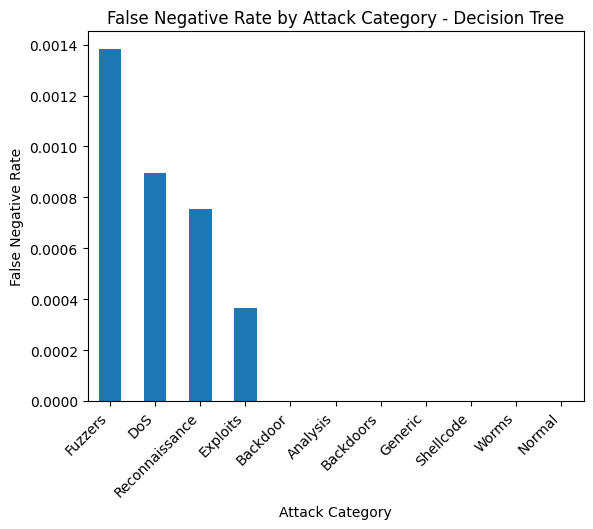

In [102]:
if "attack_cat" in error_df.columns:
    attack_category_summary.sort_values(
        by="false_negative_rate",
        ascending=False
    )["false_negative_rate"].plot(kind="bar")

    plt.title(f"False Negative Rate by Attack Category - {best_model_name}")
    plt.xlabel("Attack Category")
    plt.ylabel("False Negative Rate")
    plt.xticks(rotation=45, ha="right")
    plt.show()

It seems like most of the false negative cases fail to indentify the Fuzzers attack. It is a pattern I have noticed not just in this current configuration. This could be because of the nature of the attack since it is attacking the system by sending invalid, random or edge case inputs in order to find usable exploits.

##Error analysis by categorical network features

In [103]:
for col in ["proto", "service", "state"]:
    if col in error_df.columns:
        print(f"\nError distribution by {col}")

        table = pd.crosstab(
            error_df[col],
            error_df["prediction_type"],
            normalize="index"
        )

        display(
            table.sort_values(
                by="False Negative" if "False Negative" in table.columns else table.columns[0],
                ascending=False
            ).head(20)
        )


Error distribution by proto


prediction_type,False Negative,False Positive,True Negative,True Positive
proto,,,,
udp,0.000034,0.011545,0.931343,0.057077
tcp,0.000024,0.015241,0.947808,0.036927
3pc,0.000000,0.000000,0.000000,1.000000
any,0.000000,0.000000,0.000000,1.000000
argus,0.000000,0.000000,0.000000,1.000000
a/n,0.000000,0.000000,0.000000,1.000000
aes-sp3-d,0.000000,0.000000,0.000000,1.000000
arp,0.000000,0.000000,1.000000,0.000000
aris,0.000000,0.000000,0.000000,1.000000



Error distribution by service


prediction_type,False Negative,False Positive,True Negative,True Positive
service,,,,
-,0.000043,0.021034,0.935446,0.043478
http,0.000025,0.017205,0.893110,0.089660
dhcp,0.000000,0.000000,0.000000,1.000000
ftp,0.000000,0.017103,0.936843,0.046054
dns,0.000000,0.000026,0.946242,0.053732
ftp-data,0.000000,0.000040,0.992369,0.007591
irc,0.000000,0.000000,0.000000,1.000000
pop3,0.000000,0.000000,0.000000,1.000000
radius,0.000000,0.111111,0.000000,0.888889



Error distribution by state


prediction_type,False Negative,False Positive,True Negative,True Positive
state,,,,
ACC,0.090909,0.000000,0.909091,0.000000
RST,0.019417,0.174757,0.805825,0.000000
INT,0.000264,0.089234,0.315720,0.594782
FIN,0.000010,0.015311,0.947474,0.037205
CON,0.000009,0.000093,0.998333,0.001565
ECR,0.000000,0.000000,1.000000,0.000000
CLO,0.000000,0.028571,0.971429,0.000000
ECO,0.000000,0.000000,1.000000,0.000000
MAS,0.000000,0.000000,1.000000,0.000000


##Compare feature values for correct vs incorrect predictions

In [104]:
numeric_cols_for_error = error_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

cols_to_exclude = ["id", "label", "y_true", "y_pred", "attack_probability"]
numeric_cols_for_error = [
    col for col in numeric_cols_for_error
    if col not in cols_to_exclude
]

error_group_summary = error_df.groupby("prediction_type")[numeric_cols_for_error].mean().T

display(error_group_summary.head(30))

prediction_type,False Negative,False Positive,True Negative,True Positive
srcip,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
sport,3.423445e+04,3.583388e+04,3.255910e+04,2.761017e+04
dstip,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dsport,5.808182e+02,4.880166e+02,1.434422e+04,1.785755e+03
dur,1.234591e+01,9.511241e-01,6.185731e-01,1.321951e+00
sbytes,6.423636e+02,5.075692e+03,4.463064e+03,1.868029e+04
dbytes,2.392727e+02,9.136454e+02,4.383427e+04,1.397967e+04
sload,1.046592e+08,9.434462e+07,4.054835e+06,8.476568e+07
dload,3.919352e+03,4.633498e+03,3.147984e+06,3.441678e+04
stcpb,7.007468e+08,1.653001e+09,1.528209e+09,1.149417e+09


In [105]:
if "True Positive" in error_group_summary.columns and "False Negative" in error_group_summary.columns:
    fn_vs_tp = error_group_summary[["True Positive", "False Negative"]].copy()

    fn_vs_tp["absolute_difference"] = (
        fn_vs_tp["True Positive"] - fn_vs_tp["False Negative"]
    ).abs()

    display(
        fn_vs_tp.sort_values(
            by="absolute_difference",
            ascending=False
        ).head(20)
    )

prediction_type,True Positive,False Negative,absolute_difference
stcpb,1.149417e+09,7.007468e+08,4.486703e+08
dtcpb,1.170318e+09,1.514492e+09,3.441743e+08
sload,8.476568e+07,1.046592e+08,1.989347e+07
stime,1.423913e+09,1.423610e+09,3.033333e+05
ltime,1.423913e+09,1.423610e+09,3.033223e+05
sjit,5.247839e+03,7.175141e+04,6.650357e+04
dload,3.441678e+04,3.919352e+03,3.049743e+04
sbytes,1.868029e+04,6.423636e+02,1.803793e+04
dbytes,1.397967e+04,2.392727e+02,1.374039e+04
sport,2.761017e+04,3.423445e+04,6.624285e+03


##Threshold analysis

In [106]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_score_best >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "f2": fbeta_score(y_test, y_pred_threshold, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred_threshold),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,threshold,precision,recall,f1,f2,mcc,false_positive_rate,false_negative_rate,false_positives,false_negatives
0,0.10,0.774314,0.999548,0.872632,0.944595,0.873195,0.014816,0.000452,5806,9
1,0.15,0.774314,0.999548,0.872632,0.944595,0.873195,0.014816,0.000452,5806,9
2,0.20,0.774314,0.999548,0.872632,0.944595,0.873195,0.014816,0.000452,5806,9
3,0.25,0.774314,0.999548,0.872632,0.944595,0.873195,0.014816,0.000452,5806,9
4,0.30,0.774839,0.999448,0.872926,0.944679,0.873463,0.014770,0.000552,5788,11
5,0.35,0.775050,0.999448,0.873060,0.944742,0.873590,0.014752,0.000552,5781,11
6,0.40,0.775050,0.999448,0.873060,0.944742,0.873590,0.014752,0.000552,5781,11
7,0.45,0.775050,0.999448,0.873060,0.944742,0.873590,0.014752,0.000552,5781,11
8,0.50,0.775050,0.999448,0.873060,0.944742,0.873590,0.014752,0.000552,5781,11
9,0.55,0.775050,0.999448,0.873060,0.944742,0.873590,0.014752,0.000552,5781,11


##Error Analysis Summary

Error analysis was performed by separating predictions into true positives, true negatives, false positives, and false negatives. False positives represent normal traffic that would generate unnecessary IDS alerts. False negatives represent attack traffic that would bypass the IDS, making them particularly important in cybersecurity.

The analysis also examined whether errors were concentrated in specific attack categories, protocols, services, or connection states. This is important because high overall binary classification performance can hide poor detection of rare or difficult attack categories.

A threshold analysis was also performed to study the trade-off between detecting more attacks and reducing false alarms.

#Executive Summary

This project critically evaluates and reproduces the blog post “Building an Intrusion Detection System on UNSW-NB15 Dataset Based on Machine Learning Algorithm” by Subrata Maji. The source presents a machine-learning pipeline for building a binary Intrusion Detection System (IDS), where each network traffic record is classified as either normal traffic or attack traffic.

The dataset used in this project is UNSW-NB15, a benchmark cybersecurity dataset containing normal traffic and several categories of network attacks. The full dataset contains network-flow features such as protocol, service, connection state, packet counts, byte counts, duration-related features, and attack labels. These features make the dataset suitable for supervised intrusion detection experiments.

The original source proposes a standard data-science workflow: loading and cleaning the data, performing exploratory data analysis, engineering features, training multiple machine-learning models, and comparing their performance. In my reproduction, I followed the same general methodology using the full UNSW-NB15 CSV dataset. This was important because an earlier smaller train-test version of the dataset produced a different setup, while the full dataset matched the blog’s description more closely and produced results closer to the original reported behavior.

The main task was binary classification using the label column, where 0 represents normal traffic and 1 represents attack traffic. The attack_cat column was not used as an input feature because it directly describes the attack type and would cause target leakage. The id column was also removed because it is an artificial identifier rather than a meaningful network-behavior feature.

The feature-engineering process included handling categorical and numerical features separately. Categorical features such as proto, service, and state were encoded using one-hot encoding. Numerical features were standardized where appropriate, and skewed non-negative numerical features were considered for logarithmic transformation. These preprocessing steps were implemented using a machine-learning pipeline to reduce the risk of inconsistent preprocessing and data leakage.

Several classification models were trained and evaluated, including Logistic Regression, Decision Tree, and Random Forest. Logistic Regression served as a simple linear baseline, while Decision Tree and Random Forest represented tree-based models that can capture nonlinear relationships and feature interactions. The models were evaluated using accuracy, precision, recall, F1 score, F2 score, Matthews Correlation Coefficient, ROC-AUC, false positive rate, false negative rate, and confusion matrices.

The results support the author’s main claim that machine-learning models can detect attacks in the UNSW-NB15 dataset. In particular, the tree-based models achieved strong performance and produced results close to those reported in the original blog. The Decision Tree achieved very high recall, meaning that it detected almost all attack samples. This is important in an IDS context because false negatives represent attacks that pass undetected.

However, the results should still be interpreted carefully. Strong binary classification performance on UNSW-NB15 does not automatically prove that the model is suitable for real-world intrusion detection. Real network environments can change over time, and new attacks may differ from the patterns in the dataset. In addition, binary classification can hide weaknesses across specific attack categories. A model may perform well overall while still missing rare or difficult attacks.

Overall, the project confirms that the author’s methodology is useful as an educational machine-learning IDS pipeline. The results support the use of supervised learning for binary intrusion detection on UNSW-NB15. At the same time, a stronger evaluation would require attack-category-level error analysis, temporal validation, testing on additional datasets, and a deeper discussion of false positives and false negatives in real security operations.

#Summing It Up

This project examined whether the machine-learning IDS approach presented in the selected blog post is supported by reproducible experiments and meaningful evaluation. The selected source was Subrata Maji’s blog post and GitHub repository on building an Intrusion Detection System using the UNSW-NB15 dataset.

The problem addressed by the source is binary network intrusion detection. Each network traffic record must be classified as either normal or malicious. This is an important cybersecurity problem because organizations need to detect attacks while avoiding excessive false alarms.

The dataset used was UNSW-NB15, a standard benchmark dataset for intrusion detection. It contains normal traffic, multiple attack categories, and numerical and categorical network-flow features. In this project, I used the full four-file CSV version of the dataset because it more closely matched the original blog’s description and produced results closer to the author’s reported results.

The methodology followed a supervised machine-learning pipeline. First, the data was loaded and inspected. Then exploratory data analysis was performed to understand label distribution, attack categories, feature types, missing values, outliers, correlations, and possible redundancy. Feature engineering was then applied to remove leakage columns, encode categorical features, scale numerical features, and prepare the data for model training.

The main models trained were Logistic Regression, Decision Tree, and Random Forest. Logistic Regression was used as a simple baseline, while the tree-based models were used because the original source emphasized their strong performance. The models were evaluated using multiple metrics, including accuracy, precision, recall, F1, F2, MCC, ROC-AUC, false positive rate, false negative rate, and confusion matrices.

The reproduction results were close to the original blog’s results after switching to the full dataset. This supports the author’s main claim that machine-learning models can distinguish between normal and attack traffic in UNSW-NB15. The tree-based models performed especially well, and the Decision Tree achieved very high recall, which is valuable in intrusion detection because missed attacks are usually more dangerous than extra alerts.

At the same time, the project shows that high performance on this dataset should not be interpreted as proof of real-world IDS reliability. The original source mainly focuses on binary classification metrics, but real cybersecurity systems also require analysis by attack category, time-based generalization, and operational error costs. False negatives can allow attacks to pass undetected, while false positives can overload analysts with unnecessary alerts.

The most important insight from the reproduction is that dataset version matters. When using a smaller processed train-test version, the setup differed from the original blog. When using the full CSV dataset, the experiment became much closer to the source and produced more comparable results. This highlights the importance of precise dataset documentation in reproducible cybersecurity research.

In conclusion, I recommend the selected project as a useful educational example of applying machine learning to intrusion detection. The author’s main conclusion is mostly justified within the UNSW-NB15 dataset. However, I would not treat the resulting model as a complete real-world IDS without further validation. Future improvements should include attack-category-level evaluation, temporal testing, additional datasets, stronger error analysis, and clearer documentation of preprocessing and feature-selection steps.

#<font color="red">Changes After Second Review

##Review 1

After receiving feedback, I added an explicit duplicate-row analysis. I checked how many exact duplicate rows existed in the concatenated raw dataset and measured direct train-test duplicate overlap after a random split. Because duplicate overlap can lead to overly optimistic results, I repeated the main experiment after removing exact duplicate rows before splitting.

I also updated the notebook and report to clarify that the executed reproduction includes Logistic Regression and Decision Tree only. Random Forest is discussed in the original blog, but it was not included in my executed reproduction, so unsupported Random Forest claims were removed from my results and conclusions.

Finally, I updated the interpretation of the results to clarify that strong performance on a random split of UNSW-NB15 does not prove reliable detection on future traffic, unseen hosts, or another network.

##Review 2
After receiving feedback, I reran the logistic regression model with a bigger max_iter to confirm convergence as well as a cross validation (including mean and std) for F2, MCC, ROC-AUC, and Average Precision.